# Basic Concepts

Introduction to systematic/algorithmic trading.


## Russell 2000 Index


In [ ]:
import os
import sys
from datetime import datetime
from scipy.optimize import minimize
from scipy.stats import linregress

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats

# Define the path to the /src directory
src_path = os.path.abspath(os.path.join("..", "src"))

# Check if the path is already in sys.path to avoid duplication
if src_path not in sys.path:
    sys.path.append(src_path)

# from modules.portfolio import sharpe_ratio

ModuleNotFoundError: No module named 'modules.portfolio'

In [ ]:
rut_df = pd.read_csv("../mock_data/RUT.csv", index_col="Date", parse_dates=True)

<Axes: title={'center': 'Adjusted Close of Russell 2000 Index'}, xlabel='Date'>

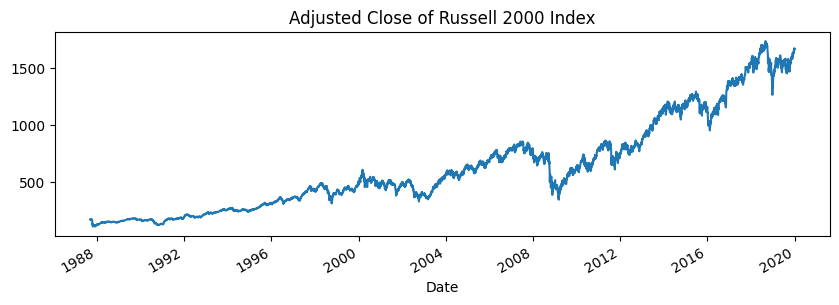

In [ ]:
plt.figure(figsize=(10, 3), dpi=100)
plt.title("Adjusted Close of Russell 2000 Index")
rut_df["Adj Close"].plot(kind="line")

## Sharpe Ratio

- The Sharpe Ratio is a measure used to assess the risk-adjusted return of an investment or portfolio.
- It indicates how much excess return is received for the extra volatility (risk) endured by holding a risky asset compared to a risk-free asset.
- **Formula**
  - $\text{Sharpe Ratio} = \frac{R_p - R_f}{\sigma_p}$
- **Where**:
  - $R_p$ = Return of the portfolio or investment
  - $R_f$ = Risk-free rate (return of a risk-free asset, like government bonds)
  - $\sigma_p$ = Standard deviation of the portfolio’s excess return (a measure of risk)
- **Interpretation**
  - **Sharpe Ratio > 1**: Indicates a good risk-adjusted return.
  - **Sharpe Ratio = 1**: Indicates an acceptable risk-adjusted return (S&P 500)
  - **Sharpe Ratio < 1**: Indicates a poor risk-adjusted return.
  - Higher Sharpe Ratios (>2) are preferred as they imply better risk-adjusted performance.
- **Limitations**
  - **Assumes Normal Distribution**: The Sharpe Ratio assumes that returns are normally distributed, which may not always be the case.
  - **Ignores Skewness and Kurtosis**: It does not account for the potential for extreme events (tail risks) in the distribution of returns.
  - **Static Measure**: It is a snapshot and does not account for changes in risk or market conditions over time.


In [ ]:
rut_df["Daily Return"] = rut_df["Adj Close"].pct_change(1)
rut_df = rut_df.dropna()  # drops first row where Daily Return is NaN

In [ ]:
rut_std = rut_df["Daily Return"].std()

In [ ]:
def compute_sharpe_ratio(
    df,
    daily_return_column="Daily Return",
    risk_free_rate: float = 0.0,
    is_annual_ratio: bool = True,
):

    mean_return = df[daily_return_column].mean()
    std = rut_df[daily_return_column].std()

    sharpe_ratio = (mean_return - risk_free_rate) / std

    return sharpe_ratio * (252**0.5) if is_annual_ratio else sharpe_ratio


compute_sharpe_ratio(rut_df)

0.4507934255302507

## Sortino Ratio

- The Sortino Ratio is a performance measurement tool used to evaluate the risk-adjusted return of an investment or portfolio.
- Unlike the Sharpe Ratio, which considers both upside and downside volatility, the Sortino Ratio focuses specifically on downside risk, providing a clearer view of the investment's performance in adverse conditions.
- **Formula**
  - $\text{Sortino Ratio} = \frac{R_p - R_t}{\sigma_d}$
- **Where:**
  - $R_p$ = Return of the portfolio or investment
  - $R_t$ = Target return (usually the risk-free rate or a minimum acceptable return)
  - $\sigma_d$ = Downside deviation (standard deviation of negative returns)
- **Interpretation**
  - **Sortino Ratio > 1**: Indicates good risk-adjusted performance considering downside risk.
  - **Sortino Ratio = 1**: Indicates an acceptable level of risk-adjusted return.
  - **Sortino Ratio < 1**: Indicates poor performance when factoring in downside risk.
  - Higher Sortino Ratios (>2) are preferred as they imply better performance relative to the risk of negative returns.
- **Advantages**
  - **Focus on Downside Risk**: By measuring only downside volatility, it provides a more accurate picture of risk for risk-averse investors.
  - **Target Return Flexibility**: Allows investors to set their own target return, making it adaptable to individual investment goals.
- **Limitations**
  - **Requires More Data**: Calculation of downside deviation requires historical return data and can be complex.
  - **Target Dependency**: The choice of the target return can significantly influence the Sortino Ratio, making comparisons across different investments potentially misleading.
  - **Ignores Upside Potential**: By focusing solely on downside risk, it may overlook positive performance in volatile markets.


In [ ]:
def compute_sortino_ratio(
    df,
    daily_return_column="Daily Return",
    threshold: float = 0.0,
    risk_free_rate: float = 0.0,
    is_annual_ratio: bool = True,
):

    mean_return = df[daily_return_column].mean()
    downside_std = df[df[daily_return_column] < threshold][
        daily_return_column
    ].std()  # only returns below threshold

    sharpe_ratio = (mean_return - risk_free_rate) / downside_std

    return sharpe_ratio * (252**0.5) if is_annual_ratio else sharpe_ratio


compute_sortino_ratio(rut_df)

0.570034198159496

## Probabilistic Sharpe Ratio

- The Probabilistic Sharpe Ratio (PSR) is an enhanced version of the traditional Sharpe Ratio.
- It aims to determine whether the observed Sharpe Ratio is statistically significant or likely to have occurred by chance.
- The PSR accounts for variability and adjusts for the bias that arises when evaluating multiple strategies or periods.
- Assesses the likelihood that a given Sharpe Ratio is a genuine measure of risk-adjusted performance rather than a random occurrence due to variability in returns.
- **Formula**
  - $\widehat{PSR}(SR^{*}) = P\left(\widehat{SR} > SR^{*}\right) = Z\left(\frac{(\widehat{SR} - SR^{\ast})\sqrt{n-1}}{\sqrt{1 - \hat{\gamma}_{3}\widehat{SR} + \frac{\hat{\gamma}_{4}-1}{4}\widehat{SR}^{2}}}\right)$
- **Where**:
  - $\widehat{SR}$ = Observed Sharpe Ratio
  - $SR^*$ = Benchmark Sharpe Ratio (a Sharpe Ratio threshold considered to be acceptable, e.g. 0)
  - $n$ = Number of observations
  - $Z$ = Cumulative distribution function (CDF) of a standard normal distribution
  - $\hat{\gamma}_{3}$ is the observed skewness of the returns
  - $\hat{\gamma}_{4}$ is the observed kurtosis of the returns
- **Interpretation**
  - The PSR outputs a probability value between 0 and 1:
    - **PSR close to 1**: High confidence that the observed Sharpe Ratio exceeds the benchmark and is statistically significant.
    - **PSR close to 0**: Low confidence that the observed Sharpe Ratio is genuinely higher than the benchmark.
  - A higher PSR suggests that the Sharpe Ratio is not due to randomness and is more likely to reflect actual risk-adjusted performance.
- **Advantages**
  - **Adjusts for Bias**: Accounts for the selection bias inherent in choosing multiple strategies based on their high Sharpe Ratios.
  - **More Reliable**: Provides a probabilistic interpretation, making it easier to quantify the confidence in an observed Sharpe Ratio.
- **Limitations**
  - **Complexity**: The PSR is more complex to calculate and interpret than the traditional Sharpe Ratio.
  - **Assumption of Normality**: Similar to the Sharpe Ratio, the PSR assumes that returns are normally distributed, which may not always be true.
  - **Dependence on Benchmark**: The choice of $SR^*$ as the benchmark Sharpe Ratio can significantly affect the interpretation of the PSR.


In [ ]:
def compute_probabilistic_sharpe_ratio(
    df,
    daily_return_column="Daily Return",
    risk_free_rate: float = 0.0,
    benchmark_sharpe_ratio: float = 0.0,
    is_annual_ratio: bool = True,
):

    daily_observed_sharpe_ratio = compute_sharpe_ratio(
        df, daily_return_column, risk_free_rate, is_annual_ratio=False
    )
    skew = scipy.stats.skew(df[daily_return_column])
    kurtosis = scipy.stats.kurtosis(df[daily_return_column], fisher=False)
    n = len(df)

    numerator = (daily_observed_sharpe_ratio - benchmark_sharpe_ratio) * (n - 1) ** 0.5
    denominator = (
        1
        - skew * daily_observed_sharpe_ratio
        + ((kurtosis - 1) / 4) * (daily_observed_sharpe_ratio**2)
    ) ** 0.5

    probabilistic_sharpe_ratio = scipy.stats.norm.cdf(numerator / denominator)

    return (
        probabilistic_sharpe_ratio * (252**0.5)
        if is_annual_ratio
        else probabilistic_sharpe_ratio
    )


compute_probabilistic_sharpe_ratio(rut_df, is_annual_ratio=False)

0.9945474914938986

In [ ]:
# compare with src code
sharpe_ratio.probabilistic_sharpe_ratio(rut_df["Daily Return"])

0.9945474914938986

## Portfolio Optimisation


In [ ]:
cost_df = pd.read_csv("../mock_data/COST.csv", index_col="Date", parse_dates=True)[
    "Adj Close"
]
wmt_df = pd.read_csv("../mock_data/WMT.csv", index_col="Date", parse_dates=True)[
    "Adj Close"
]
tgt_df = pd.read_csv("../mock_data/TGT.csv", index_col="Date", parse_dates=True)[
    "Adj Close"
]
dg_df = pd.read_csv("../mock_data/DG.csv", index_col="Date", parse_dates=True)[
    "Adj Close"
]

In [ ]:
retail_df = pd.concat([cost_df, wmt_df, tgt_df, dg_df], axis=1)
retail_df.columns = ["COST", "WMT", "TGT", "DG"]
retail_df

,COST,WMT,TGT,DG
Date,,,,
2016-09-06,140.896622,65.758080,60.674061,68.342621
2016-09-07,138.739395,64.911324,60.847187,68.105331
2016-09-08,136.805038,64.704163,60.120117,67.080215
2016-09-09,134.335831,63.325943,59.721989,66.994766
2016-09-12,135.218338,64.803238,59.981625,68.366478
...,...,...,...,...
2021-08-27,450.339996,146.520004,249.179993,225.250000
2021-08-30,455.929993,147.699997,249.360001,225.360001
2021-08-31,455.489990,148.100006,246.979996,222.910004


<Axes: xlabel='Date'>

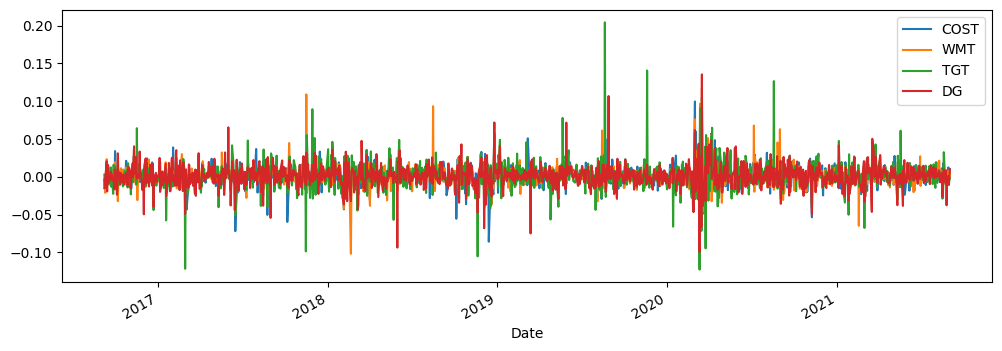

In [ ]:
retail_daily_returns_df = retail_df.pct_change(1).dropna()
retail_daily_returns_df.plot(figsize=(12, 4))

<Axes: xlabel='Date'>

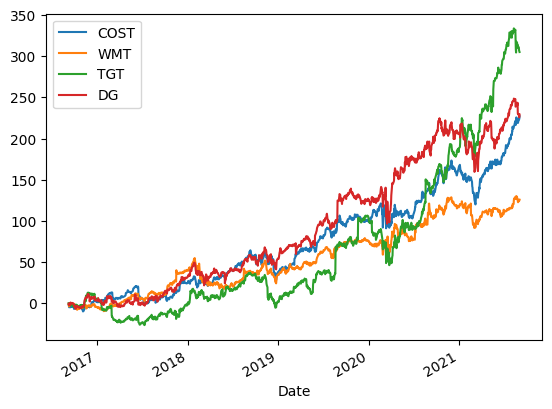

In [13]:
retail_cumulative_returns_df = ((1 + retail_daily_returns_df).cumprod() - 1) * 100
retail_cumulative_returns_df.plot()

[0.25, 0.25, 0.25, 0.25]


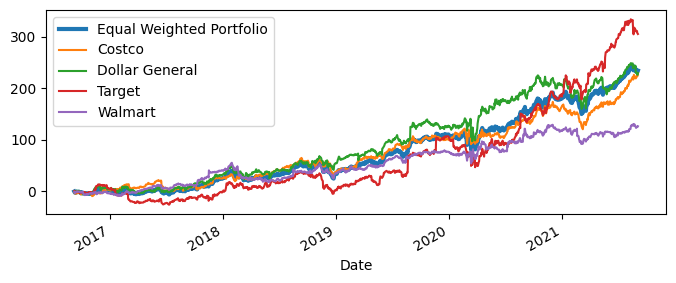

In [ ]:
n = len(retail_cumulative_returns_df.columns)
equal_weightings = n * [1 / n]
print(equal_weightings)
retail_weighted_daily_returns = np.dot(
    equal_weightings, retail_daily_returns_df.transpose()
)
retail_weighted_cumulative_returns = (
    (1 + retail_weighted_daily_returns).cumprod() - 1
) * 100  # np.dot([a, b], [x, y]) => a * x + b * y
retail_weighted_cumulative_returns_series = pd.Series(
    retail_weighted_cumulative_returns, index=retail_daily_returns_df.index
)

plt.figure(figsize=(8, 3))
retail_weighted_cumulative_returns_series.plot(
    label="Equal Weighted Portfolio", linewidth=3
)
retail_cumulative_returns_df["COST"].plot(label="Costco")
retail_cumulative_returns_df["DG"].plot(label="Dollar General")
retail_cumulative_returns_df["TGT"].plot(label="Target")
retail_cumulative_returns_df["WMT"].plot(label="Walmart")
plt.legend()

### Monte Carlo Simulation for Portfolio Optimisation


In [ ]:
log_returns_df = np.log(retail_df / retail_df.shift(1))  # logarithmic return
log_returns_df.head()

,COST,WMT,TGT,DG
Date,,,,
2016-09-06,NaN,NaN,NaN,NaN
2016-09-07,-0.015429,-0.012960,0.002849,-0.003478
2016-09-08,-0.014040,-0.003197,-0.012021,-0.015166
2016-09-09,-0.018214,-0.021530,-0.006644,-0.001275
2016-09-12,0.006548,0.023060,0.004338,0.020268


In [ ]:
N = len(retail_df.columns)


def generate_weights(n):
    weights = np.random.random(n)
    return weights / np.sum(weights)


generate_weights(N)

array([0.11579362, 0.28853806, 0.38287474, 0.21279359])

In [ ]:
def calculate_returns(weights, log_returns):
    # average daily return
    return np.sum(log_returns.mean() * weights) * 252  # annual return


calculate_returns(generate_weights(N), log_returns_df)

0.20611718000036153

In [ ]:
def calculate_volatility(weights, log_returns_covariance):
    ## annualised version of covariance matrix
    annualised_covariance = np.dot(log_returns_covariance * 252, weights)
    vol = np.dot(weights.transpose(), annualised_covariance)
    return np.sqrt(vol)


calculate_volatility(generate_weights(N), log_returns_df.cov())

0.19314025833849155

In [ ]:
monte_carlo_portfolio_returns = []
monte_carlo_portfolio_vol = []
monte_carlo_portfolio_weights = []

for simulation in range(6000):
    weights = generate_weights(N)
    monte_carlo_portfolio_weights.append(weights)

    simulation_returns = calculate_returns(weights, log_returns_df)
    monte_carlo_portfolio_returns.append(simulation_returns)

    simulation_vol = calculate_volatility(weights, log_returns_df.cov())
    monte_carlo_portfolio_vol.append(simulation_vol)

len(monte_carlo_portfolio_returns)

6000

Text(0, 0.5, 'Returns')

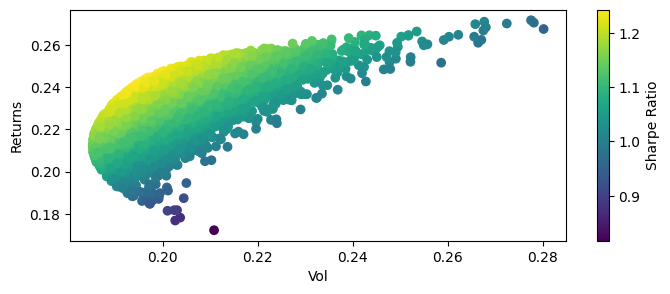

In [ ]:
monte_carlo_portfolio_sharpe_ratios = np.array(
    monte_carlo_portfolio_returns
) / np.array(monte_carlo_portfolio_vol)

plt.figure(figsize=(8, 3))
plt.scatter(
    monte_carlo_portfolio_vol,
    monte_carlo_portfolio_returns,
    c=monte_carlo_portfolio_sharpe_ratios,
)
plt.colorbar(label="Sharpe Ratio")
plt.xlabel("Vol")
plt.ylabel("Returns")

In [ ]:
monte_carlo_highest_weightings = monte_carlo_portfolio_weights[
    np.argmax(monte_carlo_portfolio_sharpe_ratios)
]
for i in range(N):
    print(f"{retail_df.columns[i]} weighting: {monte_carlo_highest_weightings[i]}")

COST weighting: 0.5376387589875777
WMT weighting: 0.004286377663718984
TGT weighting: 0.16071047908538424
DG weighting: 0.29736438426331896


### Minimization Search for Portfolio Optimisation


In [22]:
def func_to_minimize(weights):
    # find the minimum value of the negative Sharpe ratios (SR * -1)
    return (
        calculate_returns(weights, log_returns_df)
        / calculate_volatility(weights, log_returns_df.cov())
    ) * -1

In [ ]:
equal_weightings
sum_constraint = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
bounds = tuple((0, 1) for n in range(N))
bounds  # weights are between 0 and 1

((0, 1), (0, 1), (0, 1), (0, 1))

In [ ]:
optimised_weightings = minimize(
    fun=func_to_minimize, x0=equal_weightings, bounds=bounds, constraints=sum_constraint
)

print(optimised_weightings)

for i in range(N):
    print(f"{retail_df.columns[i]} weighting: {optimised_weightings['x'][i]:.3f}")

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -1.2451267776112656
       x: [ 5.846e-01  5.638e-18  1.768e-01  2.386e-01]
     nit: 4
     jac: [-3.517e-04  5.834e-02  1.120e-03  3.204e-05]
    nfev: 20
    njev: 4
COST weighting: 0.585
WMT weighting: 0.000
TGT weighting: 0.177
DG weighting: 0.239


### Efficient Frontier

- A graphical representation of the set of optimal portfolios offering the highest expected return for a given level of risk.
- Shows the trade-off between risk and return, helping investors choose portfolios based on their risk tolerance and return expectations.
- Derived by solving a series of optimization problems for different return levels, typically using mathematical tools like Monte Carlo simulations and minimization algorithms in SciPy.


In [ ]:
expected_returns_range = np.linspace(0.18, 0.28, 100)  ## from plot
constraints = (
    {"type": "eq", "fun": lambda w: np.sum(w) - 1},
    {
        "type": "eq",
        "fun": lambda w: (
            calculate_returns(weights=w, log_returns=log_returns_df) - possible_return
        ),
    },
)

In [ ]:
def calculate_volatility_to_minimize(weights):
    ## annualised version of covariance matrix
    annualised_covariance = np.dot(log_returns_df.cov() * 252, weights)
    vol = np.dot(weights.transpose(), annualised_covariance)
    return np.sqrt(vol)


frontier_vol = []
portfolio_holdings = []

for possible_return in expected_returns_range:
    result = minimize(
        fun=calculate_volatility_to_minimize,
        x0=equal_weightings,
        bounds=bounds,
        constraints=constraints,
    )

    frontier_vol.append(result["fun"])
    portfolio_holdings.append(result["x"])

frontier_vol_array = np.array(frontier_vol)
frontier_vol_index_within_tolerance = np.nonzero(
    (frontier_vol_array > 0.24) & (frontier_vol_array < 0.25)
)[0][0]  # take first in tolerance 0.24 to 0.25 vol
frontier_vol_weightings = portfolio_holdings[frontier_vol_index_within_tolerance]
for i in range(N):
    print(f"{retail_df.columns[i]} weighting: {frontier_vol_weightings[i]:.3f}")


COST weighting: 0.365
WMT weighting: 0.000
TGT weighting: 0.635
DG weighting: 0.000


Text(0.5, 1.0, 'Efficient Frontier')

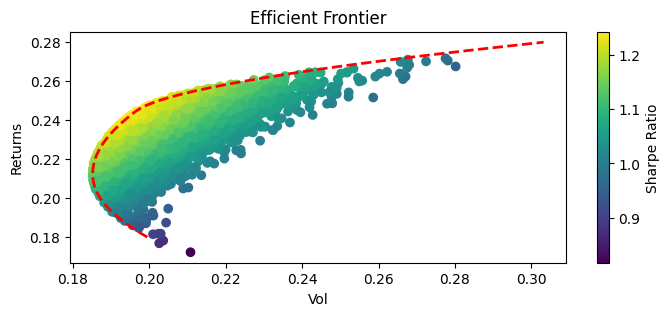

In [ ]:
plt.figure(figsize=(8, 3))
plt.scatter(
    monte_carlo_portfolio_vol,
    monte_carlo_portfolio_returns,
    c=monte_carlo_portfolio_sharpe_ratios,
)
plt.plot(frontier_vol, expected_returns_range, color="red", ls="--", lw=2)
plt.colorbar(label="Sharpe Ratio")
plt.xlabel("Vol")
plt.ylabel("Returns")
plt.title("Efficient Frontier")

## Capital Asset Pricing Model (CAPM)

- Foundational financial model used to determine the expected return on an asset based on its systematic risk, as measured by its sensitivity to market movements.
- **Formula**
  - The expected return of an asset: $E(R_{i}) = R_{f} + \beta_{i}(E(R_{m})-R_{f})$
- **Where**:
  - $E(R_{i})$ is the expected return on the asset/portfolio
  - $R_{f}$ is the risk-free rate
  - $\beta_{i}$ is the beta of the asset, a measure of an asset’s systematic risk relative to the overall market/index
  - $E(R_{m})$ is the expected return on the market/index
  - $(E(R_{m})-R_{f})$ is the market risk premium, the excess return expected from holding the asset/portfolio over a risk-free asset
- **beta** $\beta$
  - $\beta = \frac{\text{Cov}(R_{i},R_{m})}{\text{Var}(R_{m})}$
  - Given by the covariance of the asset’s return with the market return, divided by the variance of the market's return.
  - $\beta < 1$: Less volatile than the market/index, suggesting lower risk/returns.
  - $\beta > 1$: More volatile than the market, implying higher risk/returns.
  - $\beta = 1$: Moves in line with the market.
- **alpha** $\alpha$
  - $\alpha = R_{i} - [R_{f} + \beta_{i}(E(R_{m})-R_{f})]$
  - Represents the additional return (positive or negative) achieved over the expected return of the market/index for a given level of risk.
  - $\alpha > 0$: Outperformed expectations, indicating potential skill or good asset selection.
  - $\alpha = 0$: In line with the expected return for the asset's risk level.
  - $\alpha < 0$: Underperformance, possibly due to poor asset selection or ineffective strategy.
- **Security Pricing**
  - _Fairly Valued_: If the asset's actual return aligns with its CAPM-derived expected return.
  - _Undervalued_: If the actual return is higher than the CAPM-predicted return (indicating a buying opportunity).
  - _Overvalued_: If the actual return is lower than the CAPM-predicted return (suggesting the asset may be overpriced).
- **Assumptions**
  - Efficient Market: All investors have the same information and rational expectations, meaning asset prices fully reflect all available information.
  - Single-Period Investment Horizon: CAPM assumes a single time period for investment returns, typically one year.
  - No Transaction Costs or Taxes: CAPM assumes there are no trading fees or taxes, allowing investors to freely buy and sell assets.
  - Risk-averse Investors: Investors prefer less risk for a given level of return, consistent with modern portfolio theory.
  - Diversified Portfolio: CAPM assumes investors hold well-diversified portfolios to eliminate unsystematic risk, so only systematic risk (market risk) matters.
- **Limitations**
  - Simplistic Assumptions: Real-world conditions often do not align with CAPM’s assumptions, such as ignoring taxes, transaction costs, and investor behaviour.
  - Single-Factor Model: CAPM only considers market risk ($\beta$), ignoring other risk factors that may impact returns (e.g., size, value, or momentum factors, as considered in multi-factor models like the Fama-French model).
  - Historical $\beta$: CAPM relies on historical $\beta$ values, which may not accurately predict future risk if the asset's volatility changes over time.
  - Market Efficiency: CAPM assumes all investors have equal access to information, which may not hold true in practice, potentially leading to mispricing.
- **Applications**
  - Portfolio Management: CAPM helps in understanding the trade-off between risk and return, allowing investors to construct portfolios that align with their risk tolerance.
  - Stock Valuation: Investors use CAPM to estimate a fair return for an asset, helping them determine if a stock is overvalued or undervalued.
  - Performance Evaluation: CAPM can assess the performance of fund managers by comparing the actual return to the expected return based on the portfolio’s $\beta$.
- **Security Market Line (SML)**
  - Graphical representation of CAPM, plotting the expected return of assets as a function of their $\beta$.
    - Y-axis: Expected return $E(R_{i})$
    - X-axis: $\beta$
  - Assets above the SML are considered undervalued, as they offer higher returns for their level of risk.
  - Assets below the SML are considered overvalued, as they offer lower returns for their level of risk.


In [ ]:
aapl_df = pd.read_csv("../mock_data/AAPL.csv", index_col="Date", parse_dates=True)[
    "2017-01-01":"2020-01-01"
]
sp500_df = pd.read_csv("../mock_data/GSPC.csv", index_col="Date", parse_dates=True)[
    "2017-01-01":"2020-01-01"
]

In [ ]:
def compute_cumulative_return(df, get_absolute=True):
    initial_price = df["Adj Close"].iloc[0]
    final_price = df["Adj Close"].iloc[-1]
    if get_absolute:
        return final_price - initial_price
    else:
        return 100 * (final_price - initial_price) / initial_price


compute_cumulative_return(aapl_df)

45.071196

In [ ]:
def create_daily_returns(df):
    df["Daily Returns"] = df["Adj Close"].pct_change(1)
    return df.dropna()


def create_cumulative_absolute(df):
    df["Cumulative Absolute"] = df["Adj Close"] - df["Adj Close"].iloc[0]
    return df


def create_cumulative_pct_change(df):
    df["Percent Change"] = (
        100 * (df["Adj Close"] - df["Adj Close"].iloc[0]) / df["Adj Close"].iloc[0]
    )
    return df

In [31]:
aapl_df = create_daily_returns(aapl_df)
aapl_df = create_cumulative_absolute(aapl_df)
aapl_df = create_cumulative_pct_change(aapl_df)
aapl_df

,Open,High,Low,Close,Adj Close,Volume,Daily Returns,Cumulative Absolute,Percent Change
Date,,,,,,,,,
2017-01-04,28.962500,29.127501,28.937500,29.004999,27.341724,84472400,-0.001119,0.000000,0.000000
2017-01-05,28.980000,29.215000,28.952499,29.152500,27.480770,88774400,0.005085,0.139046,0.508549
2017-01-06,29.195000,29.540001,29.117500,29.477501,27.787130,127007600,0.011148,0.445406,1.629034
2017-01-09,29.487499,29.857500,29.485001,29.747499,28.041647,134247600,0.009160,0.699923,2.559908
2017-01-10,29.692499,29.844999,29.575001,29.777500,28.069925,97848400,0.001008,0.728201,2.663332
...,...,...,...,...,...,...,...,...,...
2019-12-24,71.172501,71.222504,70.730003,71.067497,70.129517,48478800,0.000951,42.787793,156.492667
2019-12-26,71.205002,72.495003,71.175003,72.477501,71.520905,93121200,0.019840,44.179181,161.581548
2019-12-27,72.779999,73.492500,72.029999,72.449997,71.493759,146266000,-0.000380,44.152035,161.482264


In [32]:
sp500_df = create_daily_returns(sp500_df)
sp500_df = create_cumulative_absolute(sp500_df)
sp500_df = create_cumulative_pct_change(sp500_df)
sp500_df

,Open,High,Low,Close,Adj Close,Volume,Daily Returns,Cumulative Absolute,Percent Change
Date,,,,,,,,,
2017-01-04,2261.600098,2272.820068,2261.600098,2270.750000,2270.750000,3764890000,0.005722,0.000000,0.000000
2017-01-05,2268.179932,2271.500000,2260.449951,2269.000000,2269.000000,3761820000,-0.000771,-1.750000,-0.077067
2017-01-06,2271.139893,2282.100098,2264.060059,2276.979980,2276.979980,3339890000,0.003517,6.229980,0.274358
2017-01-09,2273.590088,2275.489990,2268.899902,2268.899902,2268.899902,3217610000,-0.003549,-1.850098,-0.081475
2017-01-10,2269.719971,2279.270020,2265.270020,2268.899902,2268.899902,3638790000,0.000000,-1.850098,-0.081475
...,...,...,...,...,...,...,...,...,...
2019-12-24,3225.449951,3226.429932,3220.510010,3223.379883,3223.379883,1296540000,-0.000195,952.629883,41.952213
2019-12-26,3227.199951,3240.080078,3227.199951,3239.909912,3239.909912,2160680000,0.005128,969.159912,42.680168
2019-12-27,3247.229980,3247.929932,3234.370117,3240.020020,3240.020020,2428670000,0.000034,969.270020,42.685017


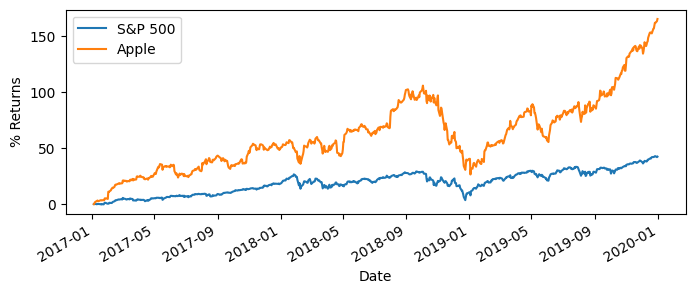

In [ ]:
plt.figure(figsize=(8, 3))
plt.ylabel("% Returns")
sp500_df["Percent Change"].plot(label="S&P 500")
aapl_df["Percent Change"].plot(label="Apple")
plt.legend()

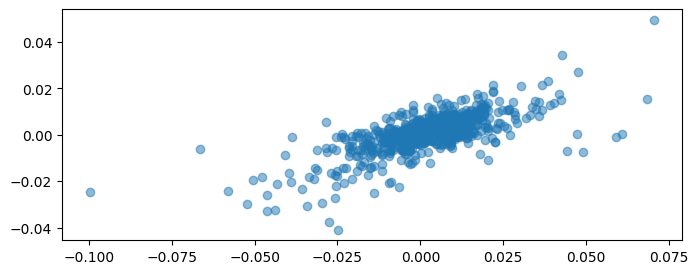

In [ ]:
plt.figure(figsize=(8, 3))
plt.scatter(
    aapl_df["Daily Returns"], sp500_df["Daily Returns"], alpha=0.5
)  # add alpha for transparency

In [ ]:
def beta_and_alpha_sp500(df):
    beta, alpha, _, _, _ = linregress(sp500_df["Daily Returns"], df["Daily Returns"])

    return beta, alpha


beta_and_alpha_sp500(sp500_df)  # expect 1 and 0

(1.0, 0.0)

In [ ]:
beta_and_alpha_sp500(aapl_df)  # AAPl outperformed the S&P 500

(1.3665697164904382, 0.00071941859186592)

## Chart Generation for Systematic Trading Notes

The following cells generate plots for the systematic trading documentation.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
from scipy.stats import norm, skewnorm

SAVE_DIR = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "documentation", "images")
)
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Charts will be saved to: {SAVE_DIR}")

Charts will be saved to: /home/matt/git-local/financial-modelling/quantitative/documentation/images


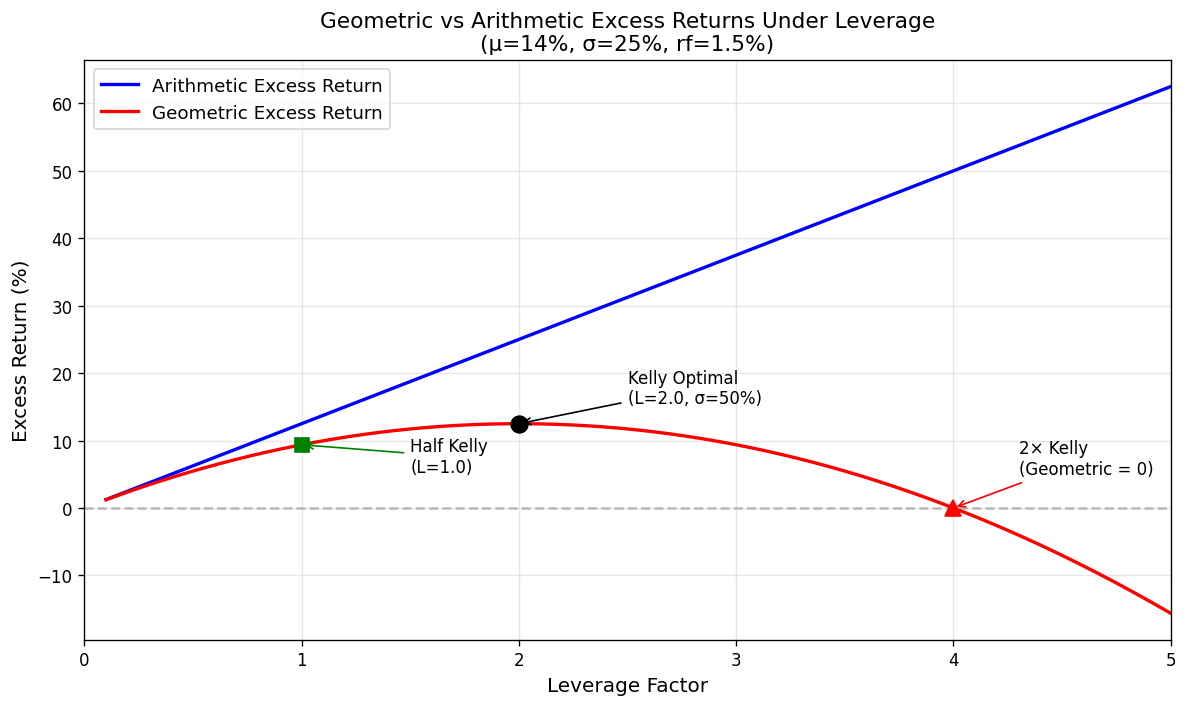

Saved: /home/matt/git-local/financial-modelling/quantitative/documentation/images/systematic-trading-kelly-leverage.png


In [ ]:
"""
Chart 1: Geometric Mean vs Leverage Factor
Demonstrates that geometric returns do not scale linearly with leverage
and that there is an optimal Kelly leverage point.
"""
# Parameters
mu_arith = 0.14  # Arithmetic mean return
sigma = 0.25  # Standard deviation
rf = 0.015  # Risk-free rate
excess = mu_arith - rf  # Excess return

leverage = np.linspace(0.1, 5.0, 200)
arith_excess = leverage * excess
# Geometric excess return approximation: L*excess - 0.5*L^2*sigma^2
geo_excess = leverage * excess - 0.5 * leverage**2 * sigma**2

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
ax.plot(
    leverage, arith_excess * 100, "b-", linewidth=2, label="Arithmetic Excess Return"
)
ax.plot(leverage, geo_excess * 100, "r-", linewidth=2, label="Geometric Excess Return")
ax.axhline(y=0, color="grey", linestyle="--", alpha=0.5)

# Mark Kelly optimal
kelly_opt = excess / sigma**2
kelly_geo = kelly_opt * excess - 0.5 * kelly_opt**2 * sigma**2
ax.plot(kelly_opt, kelly_geo * 100, "ko", markersize=10, zorder=5)
ax.annotate(
    f"Kelly Optimal\n(L={kelly_opt:.1f}, σ={kelly_opt * sigma * 100:.0f}%)",
    xy=(kelly_opt, kelly_geo * 100),
    xytext=(kelly_opt + 0.5, kelly_geo * 100 + 3),
    fontsize=10,
    arrowprops=dict(arrowstyle="->", color="black"),
)

# Mark half Kelly
half_kelly = kelly_opt / 2
half_geo = half_kelly * excess - 0.5 * half_kelly**2 * sigma**2
ax.plot(half_kelly, half_geo * 100, "gs", markersize=8, zorder=5)
ax.annotate(
    f"Half Kelly\n(L={half_kelly:.1f})",
    xy=(half_kelly, half_geo * 100),
    xytext=(half_kelly + 0.5, half_geo * 100 - 4),
    fontsize=10,
    arrowprops=dict(arrowstyle="->", color="green"),
)

# Mark twice Kelly (zero geometric return)
twice_kelly = 2 * kelly_opt
ax.plot(twice_kelly, 0, "r^", markersize=10, zorder=5)
ax.annotate(
    f"2× Kelly\n(Geometric = 0)",
    xy=(twice_kelly, 0),
    xytext=(twice_kelly + 0.3, 5),
    fontsize=10,
    arrowprops=dict(arrowstyle="->", color="red"),
)

ax.set_xlabel("Leverage Factor", fontsize=12)
ax.set_ylabel("Excess Return (%)", fontsize=12)
ax.set_title(
    "Geometric vs Arithmetic Excess Returns Under Leverage\n(μ=14%, σ=25%, rf=1.5%)",
    fontsize=13,
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 5)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/systematic-trading-kelly-leverage.png", bbox_inches="tight")
plt.show()
print(f"Saved: {SAVE_DIR}/systematic-trading-kelly-leverage.png")

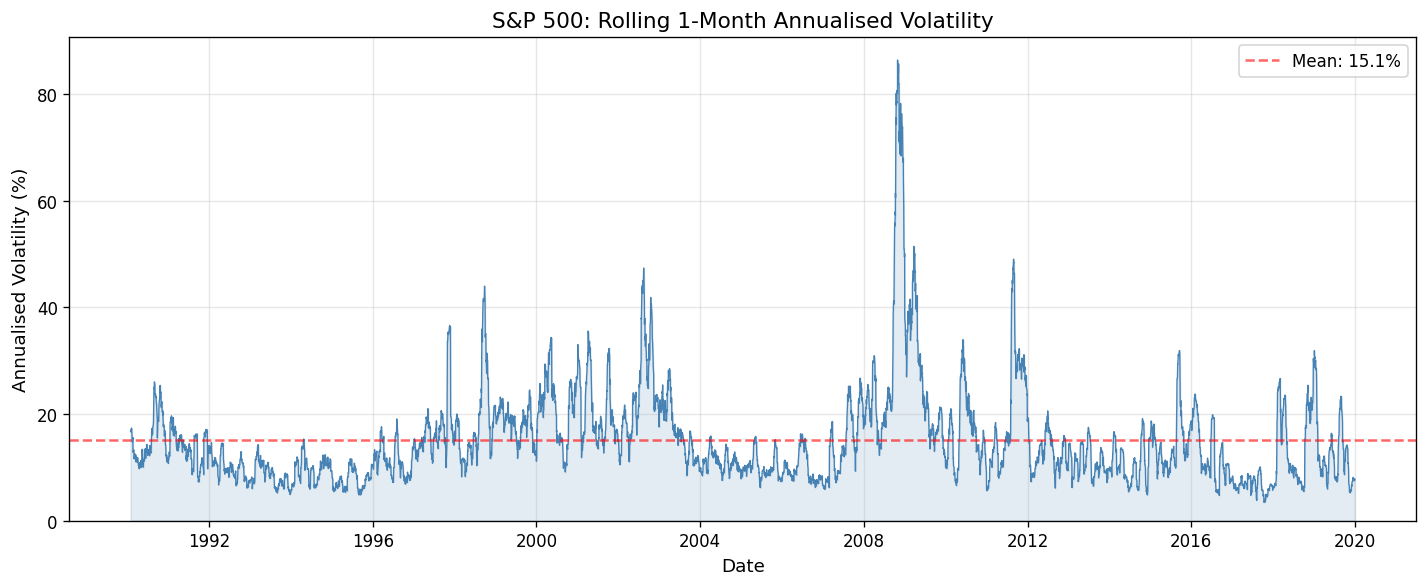

Saved: /home/matt/git-local/financial-modelling/quantitative/documentation/images/systematic-trading-sp500-rolling-vol.png


In [ ]:
"""
Chart 2: S&P 500 Rolling 1-Month Annualised Volatility
Demonstrates volatility clustering and mean reversion.
"""
gspc_df = pd.read_csv("../mock_data/GSPC.csv", index_col="Date", parse_dates=True)
gspc_df = gspc_df[gspc_df.index >= "1990-01-01"]
gspc_df["Daily Return"] = gspc_df["Adj Close"].pct_change()
gspc_df = gspc_df.dropna()

# Rolling 1-month (21 trading days) annualised volatility
gspc_df["Rolling Vol"] = (
    gspc_df["Daily Return"].rolling(window=21).std() * np.sqrt(252) * 100
)

fig, ax = plt.subplots(figsize=(12, 5), dpi=120)
ax.plot(gspc_df.index, gspc_df["Rolling Vol"], linewidth=0.8, color="steelblue")
ax.fill_between(gspc_df.index, 0, gspc_df["Rolling Vol"], alpha=0.15, color="steelblue")
ax.axhline(
    y=gspc_df["Rolling Vol"].mean(),
    color="red",
    linestyle="--",
    alpha=0.6,
    label=f"Mean: {gspc_df['Rolling Vol'].mean():.1f}%",
)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Annualised Volatility (%)", fontsize=11)
ax.set_title("S&P 500: Rolling 1-Month Annualised Volatility", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, None)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/systematic-trading-sp500-rolling-vol.png", bbox_inches="tight")
plt.show()
print(f"Saved: {SAVE_DIR}/systematic-trading-sp500-rolling-vol.png")

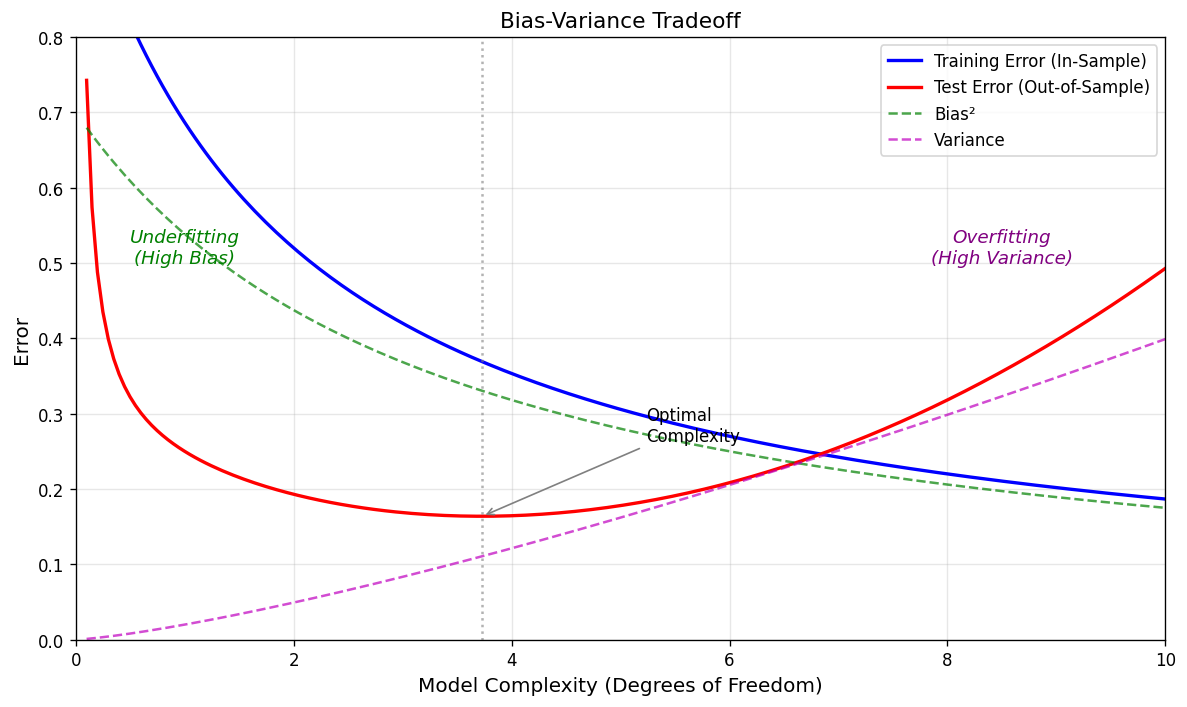

Saved: /home/matt/git-local/financial-modelling/quantitative/documentation/images/systematic-trading-bias-variance.png


In [ ]:
"""
Chart 3: Bias-Variance Tradeoff Illustration
Conceptual plot showing training vs test error as model complexity increases.
"""
complexity = np.linspace(0.1, 10, 200)
# Training error decreases monotonically
train_error = 1.0 / (1 + 0.5 * complexity) + 0.02
# Test error: U-shaped — initially decreases, then increases
test_error = 0.15 + 0.08 * (complexity - 3.5) ** 2 / 10 + 0.05 / complexity
# Bias squared (decreasing) and Variance (increasing)
bias_sq = 0.7 / (1 + 0.3 * complexity)
variance = 0.02 * complexity**1.3

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
ax.plot(complexity, train_error, "b-", linewidth=2, label="Training Error (In-Sample)")
ax.plot(complexity, test_error, "r-", linewidth=2, label="Test Error (Out-of-Sample)")
ax.plot(complexity, bias_sq, "g--", linewidth=1.5, alpha=0.7, label="Bias²")
ax.plot(complexity, variance, "m--", linewidth=1.5, alpha=0.7, label="Variance")

# Mark optimal complexity
opt_idx = np.argmin(test_error)
opt_x = complexity[opt_idx]
ax.axvline(x=opt_x, color="grey", linestyle=":", alpha=0.6)
ax.annotate(
    "Optimal\nComplexity",
    xy=(opt_x, test_error[opt_idx]),
    xytext=(opt_x + 1.5, test_error[opt_idx] + 0.1),
    fontsize=10,
    arrowprops=dict(arrowstyle="->", color="grey"),
)

# Annotate regions
ax.annotate(
    "Underfitting\n(High Bias)",
    xy=(1.0, 0.5),
    fontsize=11,
    color="green",
    ha="center",
    style="italic",
)
ax.annotate(
    "Overfitting\n(High Variance)",
    xy=(8.5, 0.5),
    fontsize=11,
    color="purple",
    ha="center",
    style="italic",
)

ax.set_xlabel("Model Complexity (Degrees of Freedom)", fontsize=12)
ax.set_ylabel("Error", fontsize=12)
ax.set_title("Bias-Variance Tradeoff", fontsize=13)
ax.legend(fontsize=10, loc="upper right")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 10)
ax.set_ylim(0, 0.8)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/systematic-trading-bias-variance.png", bbox_inches="tight")
plt.show()
print(f"Saved: {SAVE_DIR}/systematic-trading-bias-variance.png")

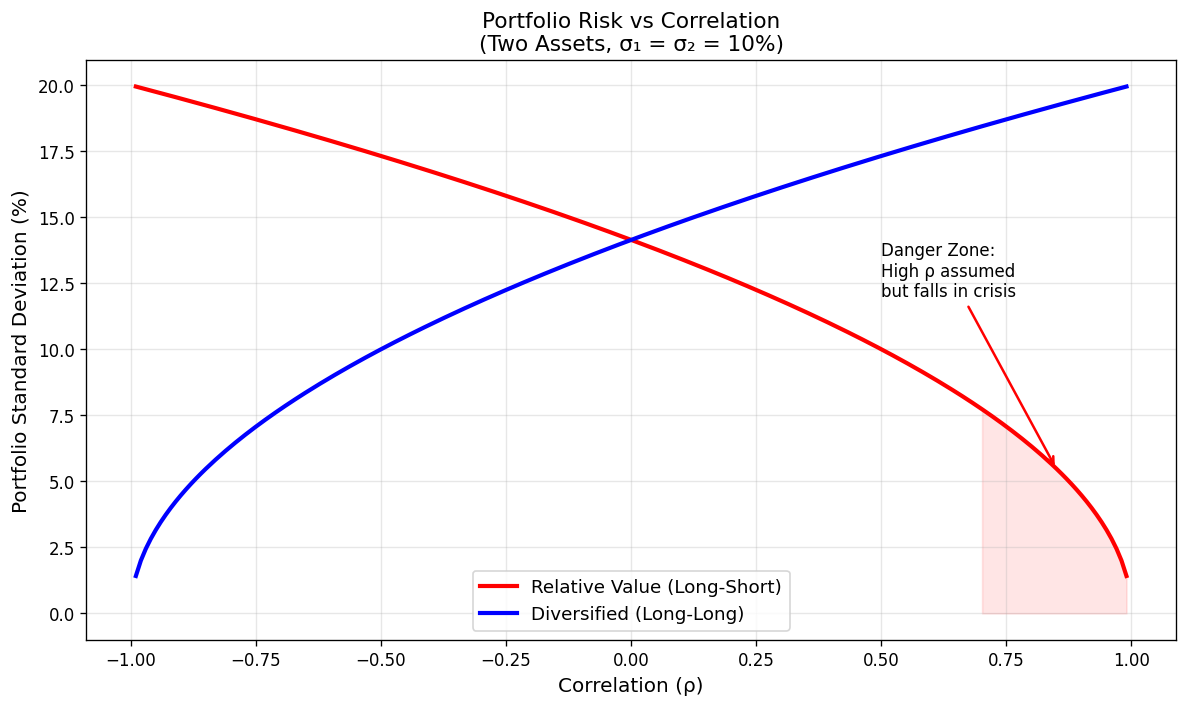

Saved: /home/matt/git-local/financial-modelling/quantitative/documentation/images/systematic-trading-correlation-risk.png


In [ ]:
"""
Chart 4: Relative Value Portfolio Risk vs Correlation
Demonstrates the danger of relative value portfolios when correlation changes.
"""
rho = np.linspace(-0.99, 0.99, 200)
sigma_asset = 10  # 10% each

# Relative value: w1=1, w2=-1
rv_risk = np.sqrt(2 * sigma_asset**2 * (1 - rho))
# Long-only: w1=1, w2=1
lo_risk = np.sqrt(2 * sigma_asset**2 * (1 + rho))

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
ax.plot(rho, rv_risk, "r-", linewidth=2.5, label="Relative Value (Long-Short)")
ax.plot(rho, lo_risk, "b-", linewidth=2.5, label="Diversified (Long-Long)")

# Highlight danger zone for relative value
ax.fill_between(rho[rho > 0.7], rv_risk[rho > 0.7], alpha=0.1, color="red")
ax.annotate(
    "Danger Zone:\nHigh ρ assumed\nbut falls in crisis",
    xy=(0.85, rv_risk[np.argmin(np.abs(rho - 0.85))]),
    xytext=(0.5, 12),
    fontsize=10,
    arrowprops=dict(arrowstyle="->", color="red", lw=1.5),
)

ax.set_xlabel("Correlation (ρ)", fontsize=12)
ax.set_ylabel("Portfolio Standard Deviation (%)", fontsize=12)
ax.set_title("Portfolio Risk vs Correlation\n(Two Assets, σ₁ = σ₂ = 10%)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/systematic-trading-correlation-risk.png", bbox_inches="tight")
plt.show()
print(f"Saved: {SAVE_DIR}/systematic-trading-correlation-risk.png")

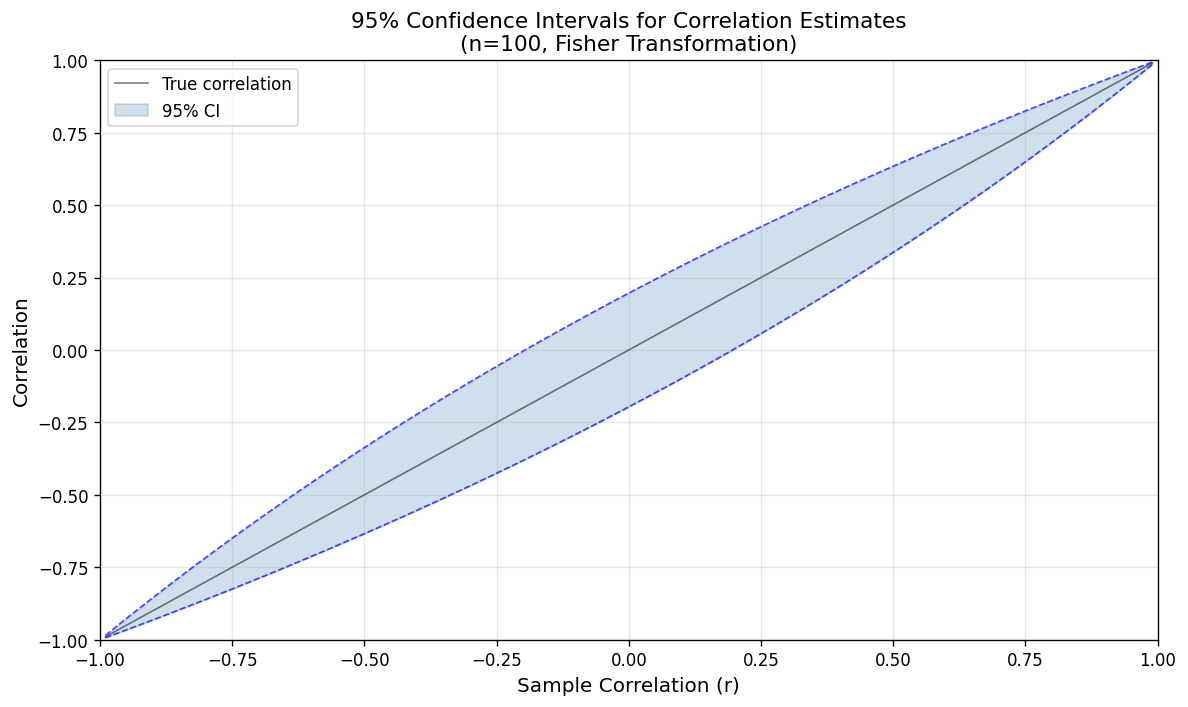

Saved: /home/matt/git-local/financial-modelling/quantitative/documentation/images/systematic-trading-correlation-ci.png


In [ ]:
"""
Chart 5: Fisher Transformation Confidence Intervals for Correlation Estimates
Shows how confidence intervals vary with the true correlation level.
"""
from scipy.stats import norm

n = 100  # sample size
alpha = 0.05
z_crit = norm.ppf(1 - alpha / 2)
r_vals = np.linspace(-0.99, 0.99, 200)

# Fisher transformation
z_r = 0.5 * np.log((1 + r_vals) / (1 - r_vals))
se = 1 / np.sqrt(n - 3)
z_L = z_r - z_crit * se
z_U = z_r + z_crit * se

# Back-transform
r_L = (np.exp(2 * z_L) - 1) / (np.exp(2 * z_L) + 1)
r_U = (np.exp(2 * z_U) - 1) / (np.exp(2 * z_U) + 1)

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
ax.plot(r_vals, r_vals, "k-", linewidth=1, alpha=0.5, label="True correlation")
ax.fill_between(r_vals, r_L, r_U, alpha=0.25, color="steelblue", label="95% CI")
ax.plot(r_vals, r_L, "b--", linewidth=1, alpha=0.7)
ax.plot(r_vals, r_U, "b--", linewidth=1, alpha=0.7)

ax.set_xlabel("Sample Correlation (r)", fontsize=12)
ax.set_ylabel("Correlation", fontsize=12)
ax.set_title(
    f"95% Confidence Intervals for Correlation Estimates\n(n={n}, Fisher Transformation)",
    fontsize=13,
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/systematic-trading-correlation-ci.png", bbox_inches="tight")
plt.show()
print(f"Saved: {SAVE_DIR}/systematic-trading-correlation-ci.png")

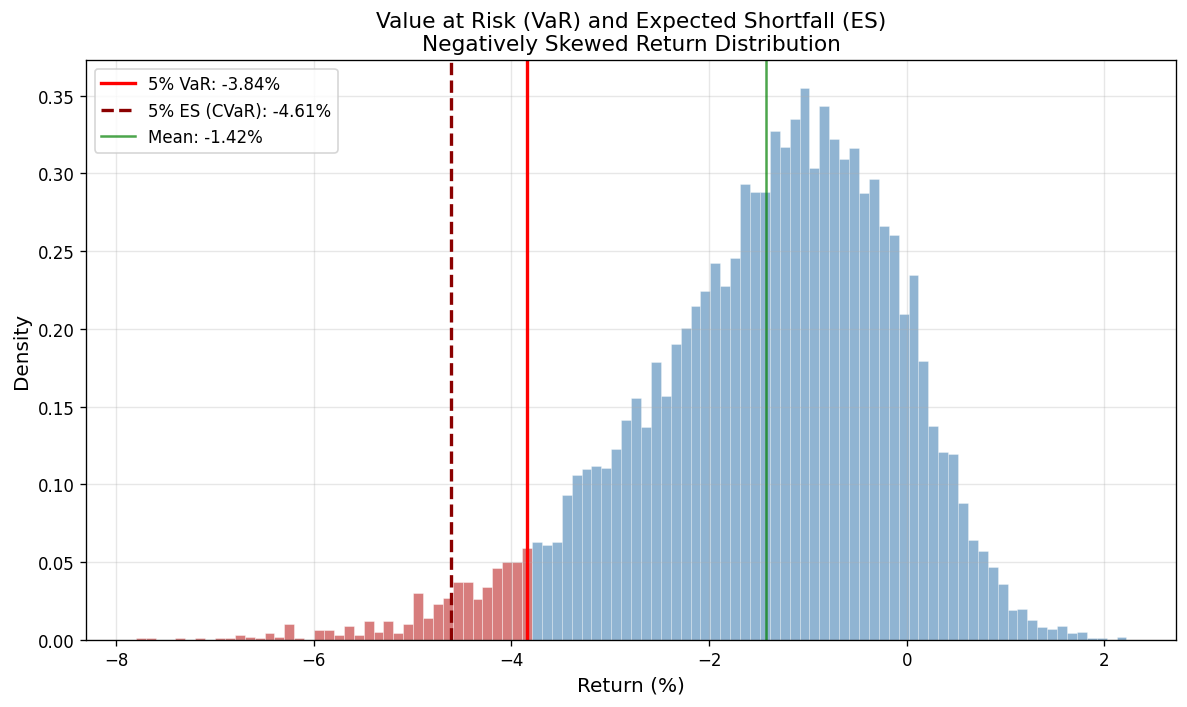

Saved: /home/matt/git-local/financial-modelling/quantitative/documentation/images/systematic-trading-var-es.png


In [ ]:
"""
Chart 6: VaR and Expected Shortfall Illustration
Shows VaR and ES on a return distribution with negative skew.
"""
from scipy.stats import skewnorm

# Generate negatively skewed returns
np.random.seed(42)
returns = skewnorm.rvs(a=-3, loc=0.001, scale=0.02, size=10000)

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
n_bins, bins, patches = ax.hist(
    returns * 100,
    bins=100,
    density=True,
    alpha=0.6,
    color="steelblue",
    edgecolor="white",
    linewidth=0.3,
)

# Calculate VaR and ES at 5%
var_5 = np.percentile(returns, 5) * 100
es_5 = returns[returns <= np.percentile(returns, 5)].mean() * 100

# Colour the tail
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge < var_5:
        patch.set_facecolor("indianred")
        patch.set_alpha(0.8)

ax.axvline(
    x=var_5, color="red", linestyle="-", linewidth=2, label=f"5% VaR: {var_5:.2f}%"
)
ax.axvline(
    x=es_5,
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"5% ES (CVaR): {es_5:.2f}%",
)
ax.axvline(
    x=np.mean(returns) * 100,
    color="green",
    linestyle="-",
    linewidth=1.5,
    alpha=0.7,
    label=f"Mean: {np.mean(returns) * 100:.2f}%",
)

ax.set_xlabel("Return (%)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(
    "Value at Risk (VaR) and Expected Shortfall (ES)\nNegatively Skewed Return Distribution",
    fontsize=13,
)
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/systematic-trading-var-es.png", bbox_inches="tight")
plt.show()
print(f"Saved: {SAVE_DIR}/systematic-trading-var-es.png")

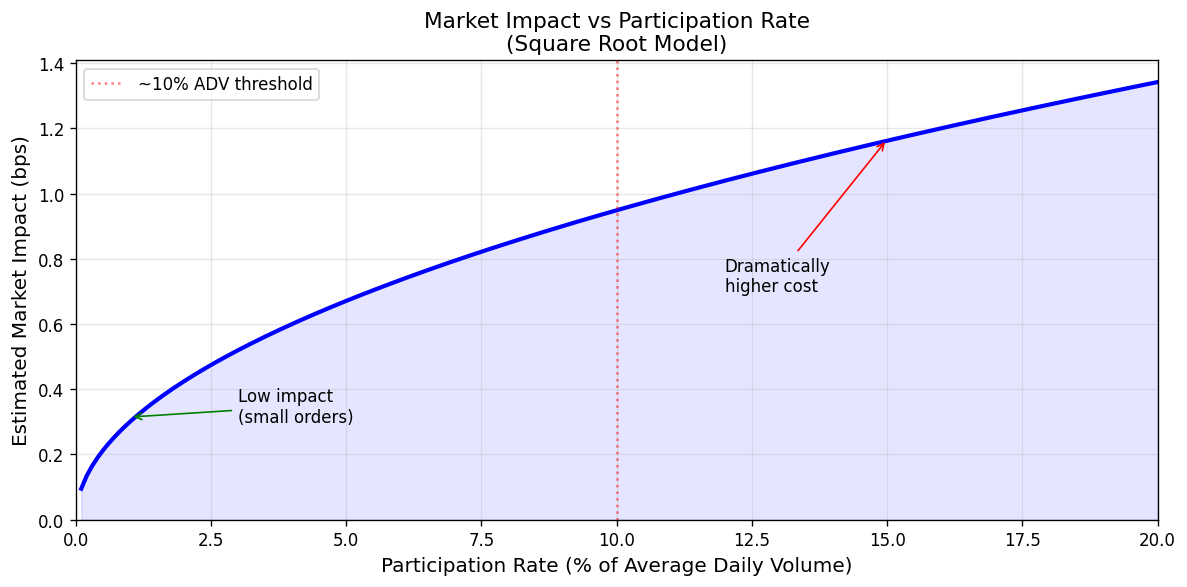

Saved: /home/matt/git-local/financial-modelling/quantitative/documentation/images/systematic-trading-market-impact.png


In [ ]:
"""
Chart 7: Market Impact vs Participation Rate
Shows the concave relationship between order size and execution cost.
"""
participation = np.linspace(0.001, 0.20, 200) * 100  # as percentage

# Square root model: impact = k * sqrt(participation)
k = 0.3
impact_bps = k * np.sqrt(participation)

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
ax.plot(participation, impact_bps, "b-", linewidth=2.5)
ax.fill_between(participation, 0, impact_bps, alpha=0.1, color="blue")

# Annotate key regions
ax.annotate(
    "Low impact\n(small orders)",
    xy=(1, impact_bps[10]),
    fontsize=10,
    xytext=(3, 0.3),
    arrowprops=dict(arrowstyle="->", color="green"),
)
ax.annotate(
    "Dramatically\nhigher cost",
    xy=(15, impact_bps[150]),
    xytext=(12, 0.7),
    fontsize=10,
    arrowprops=dict(arrowstyle="->", color="red"),
)

ax.axvline(x=10, color="red", linestyle=":", alpha=0.5, label="~10% ADV threshold")

ax.set_xlabel("Participation Rate (% of Average Daily Volume)", fontsize=12)
ax.set_ylabel("Estimated Market Impact (bps)", fontsize=12)
ax.set_title("Market Impact vs Participation Rate\n(Square Root Model)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 20)
ax.set_ylim(0, None)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/systematic-trading-market-impact.png", bbox_inches="tight")
plt.show()
print(f"Saved: {SAVE_DIR}/systematic-trading-market-impact.png")

Saved: /home/matt/git-local/financial-modelling/quantitative/documentation/images/systematic-trading-net-profit-trades.png


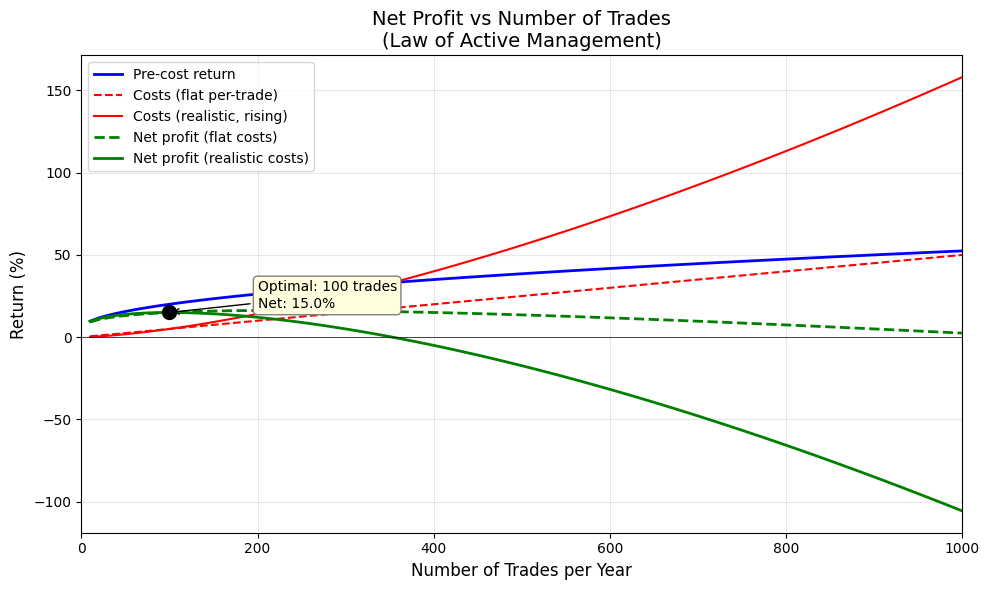

In [ ]:
# Net Profit vs Number of Trades (Law of Active Management)
# Pre-cost excess return scales with sqrt(N), costs scale linearly

fig, ax = plt.subplots(figsize=(10, 6))

trades = np.arange(10, 1001, 10)
base_excess = 15.0  # % pre-cost excess return at 100 trades
base_trades = 100
cost_per_trade_pct = 0.05  # 5% total at 100 trades => 0.05% per trade

# Pre-cost excess return scales with sqrt(N/N_base)
pre_cost_excess = base_excess * np.sqrt(trades / base_trades)
# Flat cost model
flat_costs = cost_per_trade_pct * trades
# Realistic cost model (cost per trade rises with participation)
realistic_cost_per_trade = cost_per_trade_pct * (trades / base_trades) ** 0.5
realistic_costs = realistic_cost_per_trade * trades

benchmark_return = 5.0
net_profit_flat = pre_cost_excess + benchmark_return - flat_costs
net_profit_realistic = pre_cost_excess + benchmark_return - realistic_costs

ax.plot(
    trades,
    pre_cost_excess + benchmark_return,
    "b-",
    linewidth=2,
    label="Pre-cost return",
)
ax.plot(trades, flat_costs, "r--", linewidth=1.5, label="Costs (flat per-trade)")
ax.plot(trades, realistic_costs, "r-", linewidth=1.5, label="Costs (realistic, rising)")
ax.plot(trades, net_profit_flat, "g--", linewidth=2, label="Net profit (flat costs)")
ax.plot(
    trades,
    net_profit_realistic,
    "g-",
    linewidth=2,
    label="Net profit (realistic costs)",
)

ax.axhline(y=0, color="black", linewidth=0.5, linestyle="-")

# Find and mark optimum for realistic costs
opt_idx_real = np.argmax(net_profit_realistic)
ax.plot(
    trades[opt_idx_real],
    net_profit_realistic[opt_idx_real],
    "ko",
    markersize=10,
    zorder=5,
)
ax.annotate(
    f"Optimal: {trades[opt_idx_real]} trades\nNet: {net_profit_realistic[opt_idx_real]:.1f}%",
    xy=(trades[opt_idx_real], net_profit_realistic[opt_idx_real]),
    xytext=(trades[opt_idx_real] + 100, net_profit_realistic[opt_idx_real] + 3),
    fontsize=10,
    arrowprops=dict(arrowstyle="->", color="black"),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="grey"),
)

ax.set_xlabel("Number of Trades per Year", fontsize=12)
ax.set_ylabel("Return (%)", fontsize=12)
ax.set_title("Net Profit vs Number of Trades\n(Law of Active Management)", fontsize=14)
ax.legend(fontsize=10, loc="upper left")
ax.set_xlim(0, 1000)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "systematic-trading-net-profit-trades.png"),
    dpi=150,
    bbox_inches="tight",
)
print(f"Saved: {os.path.join(SAVE_DIR, 'systematic-trading-net-profit-trades.png')}")
plt.show()

Saved: /home/matt/git-local/financial-modelling/quantitative/documentation/images/systematic-trading-net-return-participation.png


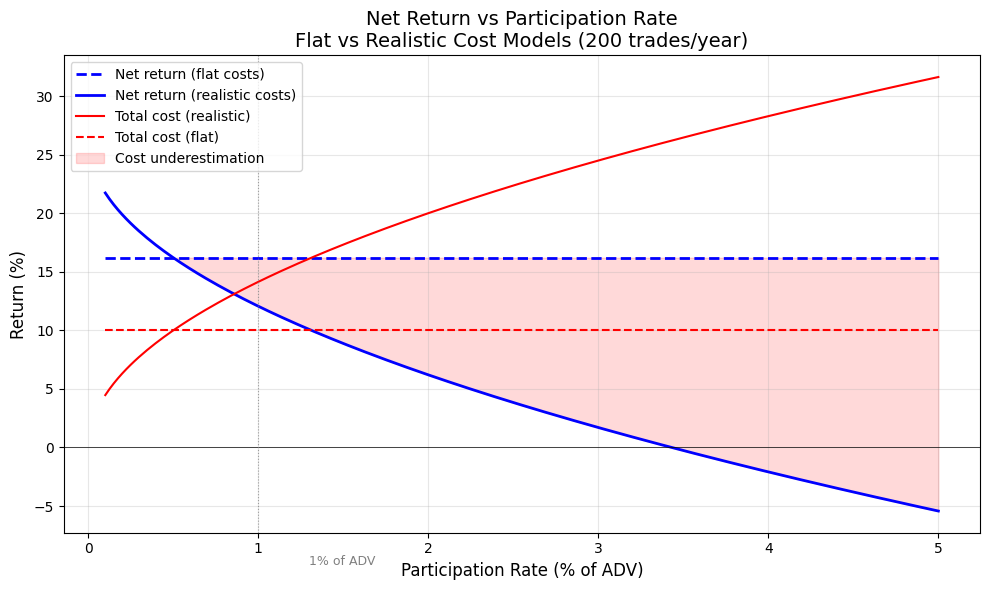

In [ ]:
# Net Return vs Participation Rate: Flat vs Realistic Costs

fig, ax = plt.subplots(figsize=(10, 6))

participation_pct = np.linspace(0.1, 5.0, 200)  # % of ADV
pre_cost_excess = 21.2  # sqrt(2) * 15% from example
benchmark = 5.0

# Flat cost model: cost per trade is constant regardless of participation
flat_cost_per_trade = 0.05  # % per trade
n_trades = 200  # doubled from 100
flat_total_cost = flat_cost_per_trade * n_trades * np.ones_like(participation_pct)

# Realistic: cost per trade rises with participation (square root model)
# At 0.5% ADV: 0.05% per trade; scales as sqrt(participation)
base_participation = 0.5
base_cost = 0.05
realistic_cost_per_trade = base_cost * np.sqrt(participation_pct / base_participation)
realistic_total_cost = realistic_cost_per_trade * n_trades

net_flat = pre_cost_excess + benchmark - flat_total_cost
net_realistic = pre_cost_excess + benchmark - realistic_total_cost

ax.plot(
    participation_pct, net_flat, "b--", linewidth=2, label="Net return (flat costs)"
)
ax.plot(
    participation_pct,
    net_realistic,
    "b-",
    linewidth=2,
    label="Net return (realistic costs)",
)
ax.plot(
    participation_pct,
    realistic_total_cost,
    "r-",
    linewidth=1.5,
    label="Total cost (realistic)",
)
ax.plot(
    participation_pct, flat_total_cost, "r--", linewidth=1.5, label="Total cost (flat)"
)

ax.axhline(y=0, color="black", linewidth=0.5)
ax.axvline(x=1.0, color="grey", linewidth=0.8, linestyle=":", alpha=0.7)
ax.annotate(
    "1% of ADV", xy=(1.0, ax.get_ylim()[0]), xytext=(1.3, -10), fontsize=9, color="grey"
)

ax.fill_between(
    participation_pct,
    net_flat,
    net_realistic,
    where=(net_flat > net_realistic),
    alpha=0.15,
    color="red",
    label="Cost underestimation",
)

ax.set_xlabel("Participation Rate (% of ADV)", fontsize=12)
ax.set_ylabel("Return (%)", fontsize=12)
ax.set_title(
    "Net Return vs Participation Rate\nFlat vs Realistic Cost Models (200 trades/year)",
    fontsize=14,
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "systematic-trading-net-return-participation.png"),
    dpi=150,
    bbox_inches="tight",
)
print(
    f"Saved: {os.path.join(SAVE_DIR, 'systematic-trading-net-return-participation.png')}"
)
plt.show()

Saved: /home/matt/git-local/financial-modelling/quantitative/documentation/images/systematic-trading-sr-vs-speed.png


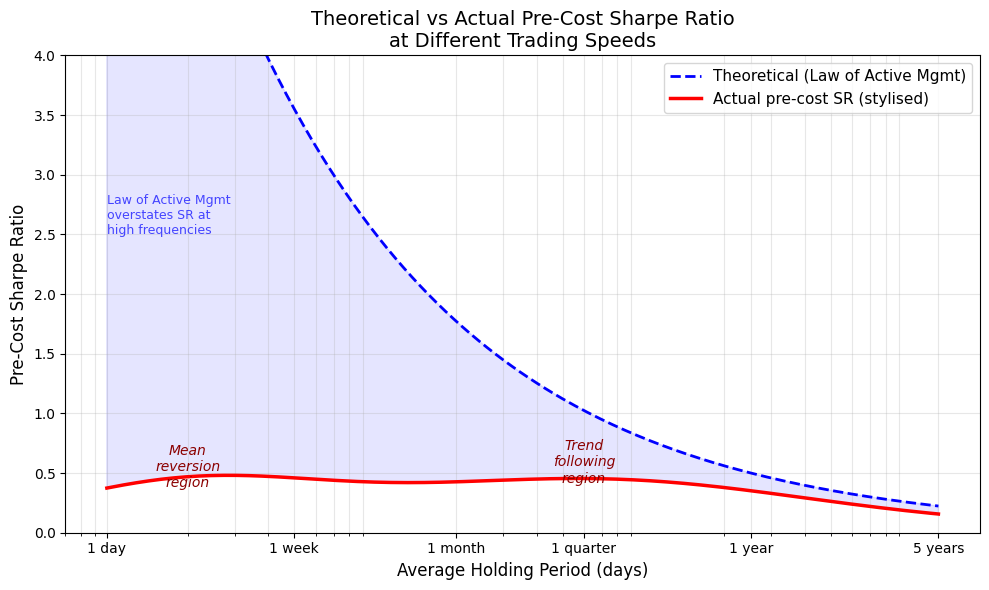

In [ ]:
# Theoretical vs Actual Pre-Cost Sharpe Ratio at Different Trading Speeds

fig, ax = plt.subplots(figsize=(10, 6))

# Holding period in days (log scale from 1 day to 5 years)
holding_days = np.logspace(0, np.log10(5 * 252), 200)
holding_years = holding_days / 252

# Theoretical SR from Law of Active Management: scales with sqrt(N)
# Base: SR = 0.5 at annual rebalancing (252 days)
base_sr = 0.5
base_holding = 252  # days
theoretical_sr = base_sr * np.sqrt(base_holding / holding_days)

# Actual SR: trend following works best at medium speeds,
# mean reversion at fast speeds, and both decay at very slow speeds
# Model as a sum of two components
trend_sr = 0.4 * np.exp(
    -0.5 * ((np.log10(holding_days) - 1.8) / 0.8) ** 2
)  # peaks ~60 days
mean_rev_sr = 0.35 * np.exp(
    -0.5 * ((np.log10(holding_days) - 0.3) / 0.5) ** 2
)  # peaks ~2 days
actual_sr = trend_sr + mean_rev_sr + 0.05  # small baseline

ax.plot(
    holding_days,
    theoretical_sr,
    "b--",
    linewidth=2,
    label="Theoretical (Law of Active Mgmt)",
)
ax.plot(
    holding_days, actual_sr, "r-", linewidth=2.5, label="Actual pre-cost SR (stylised)"
)
ax.fill_between(
    holding_days,
    actual_sr,
    theoretical_sr,
    where=(theoretical_sr > actual_sr),
    alpha=0.1,
    color="blue",
)

# Annotate regions
ax.annotate(
    "Mean\nreversion\nregion",
    xy=(2, 0.38),
    fontsize=10,
    ha="center",
    color="darkred",
    style="italic",
)
ax.annotate(
    "Trend\nfollowing\nregion",
    xy=(60, 0.42),
    fontsize=10,
    ha="center",
    color="darkred",
    style="italic",
)
ax.annotate(
    "Law of Active Mgmt\noverstates SR at\nhigh frequencies",
    xy=(1, 2.5),
    fontsize=9,
    ha="left",
    color="blue",
    alpha=0.7,
)

ax.set_xscale("log")
ax.set_xlabel("Average Holding Period (days)", fontsize=12)
ax.set_ylabel("Pre-Cost Sharpe Ratio", fontsize=12)
ax.set_title(
    "Theoretical vs Actual Pre-Cost Sharpe Ratio\nat Different Trading Speeds",
    fontsize=14,
)

# Custom x-axis labels
ax.set_xticks([1, 5, 20, 60, 252, 1260])
ax.set_xticklabels(["1 day", "1 week", "1 month", "1 quarter", "1 year", "5 years"])
ax.set_ylim(0, 4)
ax.legend(fontsize=11, loc="upper right")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "systematic-trading-sr-vs-speed.png"),
    dpi=150,
    bbox_inches="tight",
)
print(f"Saved: {os.path.join(SAVE_DIR, 'systematic-trading-sr-vs-speed.png')}")
plt.show()

In [ ]:
# Correlation Confidence Interval Plots: High-correlation pair (BAC vs JPM)
# and Low-correlation pair (AAPL vs GSPC)
# Using expanding window correlation with 95% CI via Fisher transformation

data_dir = "../mock_data"

# Load data
bac = pd.read_csv(
    os.path.join(data_dir, "BAC.csv"), parse_dates=["Date"], index_col="Date"
)
jpm = pd.read_csv(
    os.path.join(data_dir, "JPM.csv"), parse_dates=["Date"], index_col="Date"
)
aapl = pd.read_csv(
    os.path.join(data_dir, "AAPL.csv"), parse_dates=["Date"], index_col="Date"
)
gspc = pd.read_csv(
    os.path.join(data_dir, "GSPC.csv"), parse_dates=["Date"], index_col="Date"
)

# Calculate daily returns
bac_ret = bac["Close"].pct_change().dropna()
jpm_ret = jpm["Close"].pct_change().dropna()
aapl_ret = aapl["Close"].pct_change().dropna()
gspc_ret = gspc["Close"].pct_change().dropna()


def expanding_correlation_ci(ret1, ret2, min_window=60, ci=0.95):
    """Calculate expanding window correlation with Fisher transform CI."""
    # Align series
    aligned = pd.DataFrame({"r1": ret1, "r2": ret2}).dropna()
    dates = []
    corrs = []
    ci_lower = []
    ci_upper = []

    z_val = norm.ppf(1 - (1 - ci) / 2)

    for i in range(min_window, len(aligned)):
        window = aligned.iloc[:i]
        rho_hat = window["r1"].corr(window["r2"])
        n = len(window)

        # Fisher transformation
        z = 0.5 * np.log((1 + rho_hat) / (1 - rho_hat))
        se = 1 / np.sqrt(n - 3)

        z_lo = z - z_val * se
        z_hi = z + z_val * se

        # Back-transform
        rho_lo = (np.exp(2 * z_lo) - 1) / (np.exp(2 * z_lo) + 1)
        rho_hi = (np.exp(2 * z_hi) - 1) / (np.exp(2 * z_hi) + 1)

        dates.append(aligned.index[i])
        corrs.append(rho_hat)
        ci_lower.append(rho_lo)
        ci_upper.append(rho_hi)

    return (
        pd.DatetimeIndex(dates),
        np.array(corrs),
        np.array(ci_lower),
        np.array(ci_upper),
    )


# Compute for both pairs (data covers Sep 2016 – Dec 2019/Sep 2021)
dates_hc, corr_hc, ci_lo_hc, ci_hi_hc = expanding_correlation_ci(
    bac_ret, jpm_ret, min_window=120
)
dates_lc, corr_lc, ci_lo_lc, ci_hi_lc = expanding_correlation_ci(
    aapl_ret, gspc_ret, min_window=120
)

print(
    f"BAC vs JPM: final corr = {corr_hc[-1]:.3f}, CI = ({ci_lo_hc[-1]:.3f}, {ci_hi_hc[-1]:.3f}), {len(corr_hc)} observations"
)
print(
    f"AAPL vs GSPC: final corr = {corr_lc[-1]:.3f}, CI = ({ci_lo_lc[-1]:.3f}, {ci_hi_lc[-1]:.3f}), {len(corr_lc)} observations"
)

BAC vs JPM: final corr = 0.929, CI = (0.921, 0.937), 1138 observations
AAPL vs GSPC: final corr = 0.690, CI = (0.653, 0.724), 715 observations


Saved: /home/matt/git-local/financial-modelling/quantitative/documentation/images/systematic-trading-correlation-empirical.png


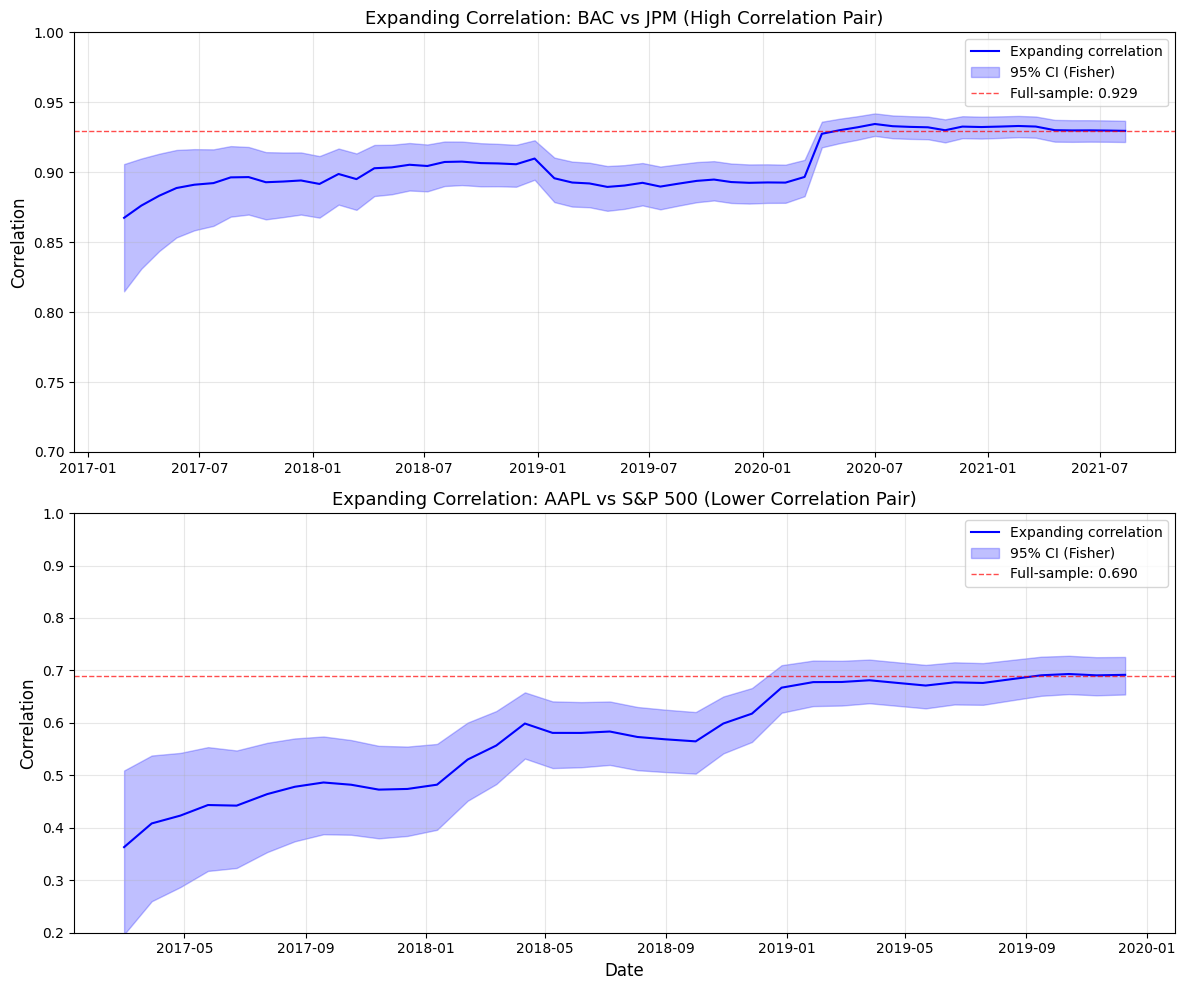

In [ ]:
# Plot 1: High-correlation pair (BAC vs JPM) — expanding correlation with CI
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# Subsample for plotting (every 20th point to keep plot clean)
step = 20
ax1.plot(
    dates_hc[::step],
    corr_hc[::step],
    "b-",
    linewidth=1.5,
    label="Expanding correlation",
)
ax1.fill_between(
    dates_hc[::step],
    ci_lo_hc[::step],
    ci_hi_hc[::step],
    alpha=0.25,
    color="blue",
    label="95% CI (Fisher)",
)
ax1.axhline(
    y=corr_hc[-1],
    color="red",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label=f"Full-sample: {corr_hc[-1]:.3f}",
)
ax1.set_ylabel("Correlation", fontsize=12)
ax1.set_title("Expanding Correlation: BAC vs JPM (High Correlation Pair)", fontsize=13)
ax1.legend(fontsize=10)
ax1.set_ylim(0.7, 1.0)
ax1.grid(True, alpha=0.3)

# Plot 2: Low-correlation pair (AAPL vs GSPC) — expanding correlation with CI
ax2.plot(
    dates_lc[::step],
    corr_lc[::step],
    "b-",
    linewidth=1.5,
    label="Expanding correlation",
)
ax2.fill_between(
    dates_lc[::step],
    ci_lo_lc[::step],
    ci_hi_lc[::step],
    alpha=0.25,
    color="blue",
    label="95% CI (Fisher)",
)
ax2.axhline(
    y=corr_lc[-1],
    color="red",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label=f"Full-sample: {corr_lc[-1]:.3f}",
)
ax2.set_xlabel("Date", fontsize=12)
ax2.set_ylabel("Correlation", fontsize=12)
ax2.set_title(
    "Expanding Correlation: AAPL vs S&P 500 (Lower Correlation Pair)", fontsize=13
)
ax2.legend(fontsize=10)
ax2.set_ylim(0.2, 1.0)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "systematic-trading-correlation-empirical.png"),
    dpi=150,
    bbox_inches="tight",
)
print(
    f"Saved: {os.path.join(SAVE_DIR, 'systematic-trading-correlation-empirical.png')}"
)
plt.show()

BAC vs JPM: 43 forecast points
AAPL vs GSPC: 22 forecast points
Saved: /home/matt/git-local/financial-modelling/quantitative/documentation/images/systematic-trading-correlation-forecast.png


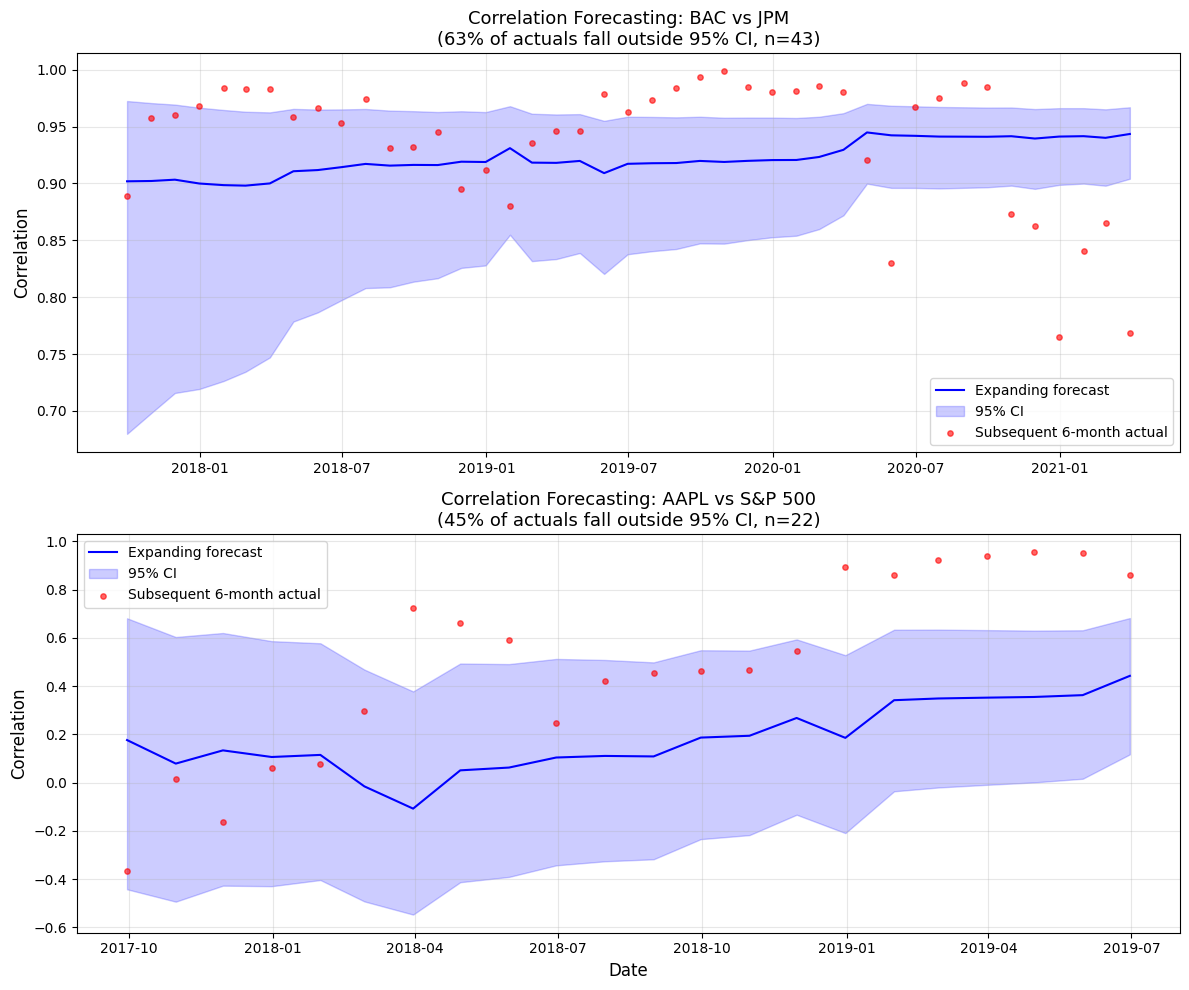

In [ ]:
# Correlation Forecasting Performance: expanding estimate + CI vs subsequent 6-month realised correlation
# Note: mock data covers 2016-2021, so we use a 6-month forward window to maximise observations


def correlation_forecast_vs_actual(ret1, ret2, min_years=1, window_months=6):
    """Compare expanding correlation forecast (with CI) against subsequent realised."""
    aligned = pd.DataFrame({"r1": ret1, "r2": ret2}).dropna()
    # Use monthly resampled returns for cleaner analysis
    monthly = aligned.resample("ME").apply(lambda x: (1 + x).prod() - 1)

    dates = []
    forecast_corr = []
    ci_lo = []
    ci_hi = []
    actual_next = []

    z_val = norm.ppf(0.975)
    min_obs = min_years * 12

    for i in range(min_obs, len(monthly) - window_months):
        past = monthly.iloc[:i]
        future = monthly.iloc[i : i + window_months]

        # Need at least 4 observations in future window for meaningful correlation
        if len(future.dropna()) < 4:
            continue

        rho_hat = past["r1"].corr(past["r2"])
        n = len(past)
        z = 0.5 * np.log((1 + rho_hat) / (1 - rho_hat))
        se = 1 / np.sqrt(n - 3)
        z_lo = z - z_val * se
        z_hi = z + z_val * se
        rho_lo = (np.exp(2 * z_lo) - 1) / (np.exp(2 * z_lo) + 1)
        rho_hi = (np.exp(2 * z_hi) - 1) / (np.exp(2 * z_hi) + 1)

        rho_actual = future["r1"].corr(future["r2"])

        dates.append(monthly.index[i])
        forecast_corr.append(rho_hat)
        ci_lo.append(rho_lo)
        ci_hi.append(rho_hi)
        actual_next.append(rho_actual)

    return (
        pd.DatetimeIndex(dates),
        np.array(forecast_corr),
        np.array(ci_lo),
        np.array(ci_hi),
        np.array(actual_next),
    )


# Compute for both pairs
d_hc, fc_hc, lo_hc, hi_hc, act_hc = correlation_forecast_vs_actual(bac_ret, jpm_ret)
d_lc, fc_lc, lo_lc, hi_lc, act_lc = correlation_forecast_vs_actual(aapl_ret, gspc_ret)

print(f"BAC vs JPM: {len(d_hc)} forecast points")
print(f"AAPL vs GSPC: {len(d_lc)} forecast points")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# High correlation pair
ax1.plot(d_hc, fc_hc, "b-", linewidth=1.5, label="Expanding forecast")
ax1.fill_between(d_hc, lo_hc, hi_hc, alpha=0.2, color="blue", label="95% CI")
ax1.scatter(
    d_hc, act_hc, c="red", s=15, alpha=0.6, zorder=5, label="Subsequent 6-month actual"
)
outside_hc = np.sum((act_hc < lo_hc) | (act_hc > hi_hc))
pct_outside_hc = 100 * outside_hc / len(act_hc) if len(act_hc) > 0 else 0
ax1.set_ylabel("Correlation", fontsize=12)
ax1.set_title(
    f"Correlation Forecasting: BAC vs JPM\n({pct_outside_hc:.0f}% of actuals fall outside 95% CI, n={len(act_hc)})",
    fontsize=13,
)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Low correlation pair
ax2.plot(d_lc, fc_lc, "b-", linewidth=1.5, label="Expanding forecast")
ax2.fill_between(d_lc, lo_lc, hi_lc, alpha=0.2, color="blue", label="95% CI")
ax2.scatter(
    d_lc, act_lc, c="red", s=15, alpha=0.6, zorder=5, label="Subsequent 6-month actual"
)
outside_lc = np.sum((act_lc < lo_lc) | (act_lc > hi_lc)) if len(act_lc) > 0 else 0
pct_outside_lc = 100 * outside_lc / len(act_lc) if len(act_lc) > 0 else 0
ax2.set_xlabel("Date", fontsize=12)
ax2.set_ylabel("Correlation", fontsize=12)
ax2.set_title(
    f"Correlation Forecasting: AAPL vs S&P 500\n({pct_outside_lc:.0f}% of actuals fall outside 95% CI, n={len(act_lc)})",
    fontsize=13,
)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "systematic-trading-correlation-forecast.png"),
    dpi=150,
    bbox_inches="tight",
)
print(f"Saved: {os.path.join(SAVE_DIR, 'systematic-trading-correlation-forecast.png')}")
plt.show()

Strategy:  Ann. Return = 6.8%, Ann. Vol = 25.7%, SR = 0.26
Benchmark: Ann. Return = 7.0%, Ann. Vol = 16.5%, SR = 0.43
Saved: /home/matt/git-local/financial-modelling/quantitative/documentation/images/systematic-trading-strategy-benchmark.png


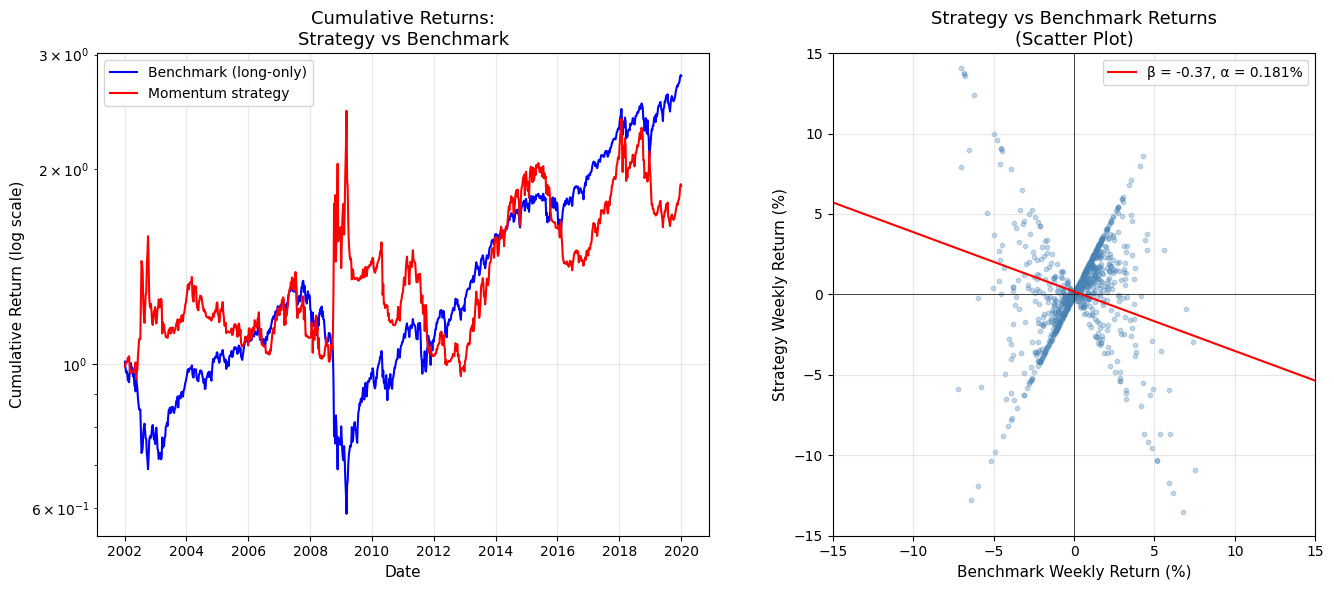

In [ ]:
# Strategy vs Benchmark: Simulated Momentum Strategy on S&P 500
# Demonstrates cumulative returns and scatter plot for benchmarking section

np.random.seed(42)

# Use GSPC data from 2000 onwards
gspc_prices = gspc.loc[gspc.index >= "2000-01-01", "Close"].copy()

# Resample to weekly prices (last price of each week) and weekly returns
weekly_prices = gspc_prices.resample("W-FRI").last().dropna()
weekly_ret = weekly_prices.pct_change().dropna()

# EWMAC momentum: fast EMA vs slow EMA of PRICES (not returns)
# Long when fast price EMA > slow price EMA (uptrend), short when below (downtrend)
fast_ema_price = weekly_prices.ewm(span=8).mean()
slow_ema_price = weekly_prices.ewm(span=32).mean()
raw_signal = fast_ema_price - slow_ema_price

# Normalise signal by rolling std of the raw signal, then clip to [-2, 2]
signal = raw_signal / raw_signal.rolling(52).std()
signal = signal.clip(-2, 2)

# Strategy return: previous week's signal × this week's return
# Align on common index after warmup
signal_aligned = signal.shift(1).loc[weekly_ret.index].dropna()
common_idx = signal_aligned.index.intersection(weekly_ret.index)
strategy_ret = (signal_aligned.loc[common_idx] * weekly_ret.loc[common_idx]).dropna()
# Skip first year of warmup for the rolling std
strategy_ret = strategy_ret.iloc[52:]
benchmark_ret_weekly = weekly_ret.loc[strategy_ret.index]

# Cumulative returns
cum_strategy = (1 + strategy_ret).cumprod()
cum_benchmark = (1 + benchmark_ret_weekly).cumprod()

# Print summary stats
strat_ann_ret = strategy_ret.mean() * 52 * 100
strat_ann_vol = strategy_ret.std() * np.sqrt(52) * 100
bench_ann_ret = benchmark_ret_weekly.mean() * 52 * 100
bench_ann_vol = benchmark_ret_weekly.std() * np.sqrt(52) * 100
print(
    f"Strategy:  Ann. Return = {strat_ann_ret:.1f}%, Ann. Vol = {strat_ann_vol:.1f}%, "
    f"SR = {strat_ann_ret / strat_ann_vol:.2f}"
)
print(
    f"Benchmark: Ann. Return = {bench_ann_ret:.1f}%, Ann. Vol = {bench_ann_vol:.1f}%, "
    f"SR = {bench_ann_ret / bench_ann_vol:.2f}"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Cumulative returns
ax1.plot(
    cum_benchmark.index,
    cum_benchmark.values,
    "b-",
    linewidth=1.5,
    label="Benchmark (long-only)",
)
ax1.plot(
    cum_strategy.index,
    cum_strategy.values,
    "r-",
    linewidth=1.5,
    label="Momentum strategy",
)
ax1.set_xlabel("Date", fontsize=11)
ax1.set_ylabel("Cumulative Return (log scale)", fontsize=11)
ax1.set_title("Cumulative Returns:\nStrategy vs Benchmark", fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_yscale("log")

# Scatter plot
ax2.scatter(
    benchmark_ret_weekly.values * 100,
    strategy_ret.values * 100,
    alpha=0.3,
    s=10,
    c="steelblue",
)
ax2.axhline(y=0, color="black", linewidth=0.5)
ax2.axvline(x=0, color="black", linewidth=0.5)

# Add regression line
from numpy.polynomial.polynomial import polyfit

b_coef, m_coef = polyfit(
    benchmark_ret_weekly.values * 100, strategy_ret.values * 100, 1
)
x_line = np.linspace(-15, 15, 100)
ax2.plot(
    x_line,
    b_coef + m_coef * x_line,
    "r-",
    linewidth=1.5,
    label=f"β = {m_coef:.2f}, α = {b_coef:.3f}%",
)
ax2.set_xlabel("Benchmark Weekly Return (%)", fontsize=11)
ax2.set_ylabel("Strategy Weekly Return (%)", fontsize=11)
ax2.set_title("Strategy vs Benchmark Returns\n(Scatter Plot)", fontsize=13)
ax2.legend(fontsize=10)
ax2.set_xlim(-15, 15)
ax2.set_ylim(-15, 15)
ax2.set_aspect("equal")
ax2.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "systematic-trading-strategy-benchmark.png"),
    dpi=150,
    bbox_inches="tight",
)
print(f"Saved: {os.path.join(SAVE_DIR, 'systematic-trading-strategy-benchmark.png')}")
plt.show()

In [ ]:
# EWMAC Brute Force Heatmap and T-Test Heatmap
# Illustrative: simulating EWMAC parameter sweep on S&P 500

# Use daily S&P 500 returns from 2000
gspc_close = gspc.loc[gspc.index >= "2000-01-01", "Close"].copy()

# Parameter grid for EWMAC: A (fast span), B (slow span)
A_vals = np.arange(2, 102, 2)  # 50 values
B_vals = np.arange(2, 252, 5)  # 50 values

# Calculate Sharpe Ratios for all A, B combinations
sr_grid = np.full((len(B_vals), len(A_vals)), np.nan)

for i, b_span in enumerate(B_vals):
    for j, a_span in enumerate(A_vals):
        fast_ema = gspc_close.ewm(span=a_span).mean()
        slow_ema = gspc_close.ewm(span=b_span).mean()

        # Signal: fast - slow (momentum when A < B)
        signal = fast_ema - slow_ema
        signal_norm = signal / signal.rolling(60).std()
        signal_norm = signal_norm.clip(-2, 2)

        # Returns
        daily_ret = gspc_close.pct_change()
        strat_ret = (signal_norm.shift(1) * daily_ret).dropna()
        strat_ret = strat_ret.iloc[max(a_span, b_span) + 60 :]  # skip warmup

        if len(strat_ret) > 252:
            ann_ret = strat_ret.mean() * 252
            ann_vol = strat_ret.std() * np.sqrt(252)
            if ann_vol > 0:
                sr_grid[i, j] = ann_ret / ann_vol

print(f"Grid computed: {sr_grid.shape}")
print(f"SR range: {np.nanmin(sr_grid):.2f} to {np.nanmax(sr_grid):.2f}")
print(
    f"Best A={A_vals[np.unravel_index(np.nanargmax(sr_grid), sr_grid.shape)[1]]}, "
    f"B={B_vals[np.unravel_index(np.nanargmax(sr_grid), sr_grid.shape)[0]]}, "
    f"SR={np.nanmax(sr_grid):.2f}"
)

Grid computed: (50, 50)
SR range: -0.58 to 0.67
Best A=4, B=2, SR=0.67


Saved: /home/matt/git-local/financial-modelling/quantitative/documentation/images/systematic-trading-ewmac-heatmap.png


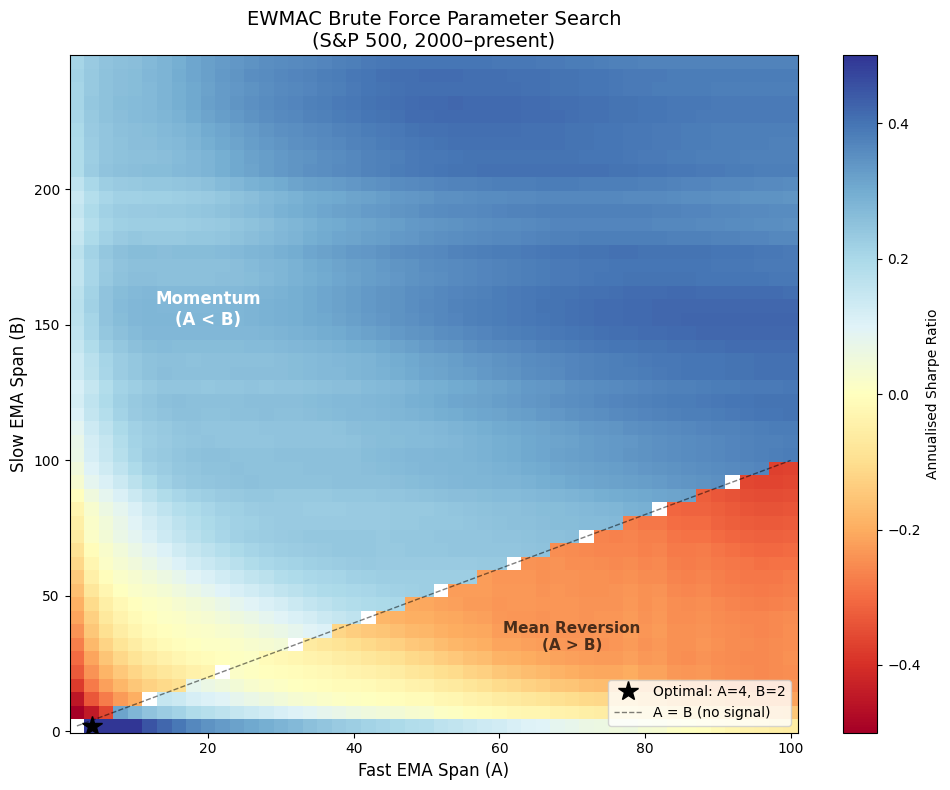

In [ ]:
# Plot: EWMAC Brute Force Heatmap

fig, ax = plt.subplots(figsize=(10, 8))

# Mask the diagonal where A == B (no signal)
masked_grid = sr_grid.copy()

im = ax.pcolormesh(
    A_vals, B_vals, masked_grid, cmap="RdYlBu", shading="auto", vmin=-0.5, vmax=0.5
)
cbar = fig.colorbar(im, ax=ax, label="Annualised Sharpe Ratio")

# Mark optimal
best_idx = np.unravel_index(np.nanargmax(sr_grid), sr_grid.shape)
best_a = A_vals[best_idx[1]]
best_b = B_vals[best_idx[0]]
ax.plot(best_a, best_b, "k*", markersize=15, label=f"Optimal: A={best_a}, B={best_b}")

# Add diagonal line (A = B, no signal)
ax.plot([2, 100], [2, 100], "k--", linewidth=1, alpha=0.5, label="A = B (no signal)")

# Annotations
ax.annotate(
    "Momentum\n(A < B)",
    xy=(20, 150),
    fontsize=12,
    ha="center",
    color="white",
    fontweight="bold",
)
ax.annotate(
    "Mean Reversion\n(A > B)",
    xy=(70, 30),
    fontsize=11,
    ha="center",
    color="black",
    alpha=0.7,
    fontweight="bold",
)

ax.set_xlabel("Fast EMA Span (A)", fontsize=12)
ax.set_ylabel("Slow EMA Span (B)", fontsize=12)
ax.set_title("EWMAC Brute Force Parameter Search\n(S&P 500, 2000–present)", fontsize=14)
ax.legend(fontsize=10, loc="lower right")

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "systematic-trading-ewmac-heatmap.png"),
    dpi=150,
    bbox_inches="tight",
)
print(f"Saved: {os.path.join(SAVE_DIR, 'systematic-trading-ewmac-heatmap.png')}")
plt.show()

Saved: /home/matt/git-local/financial-modelling/quantitative/documentation/images/systematic-trading-ttest-heatmap.png


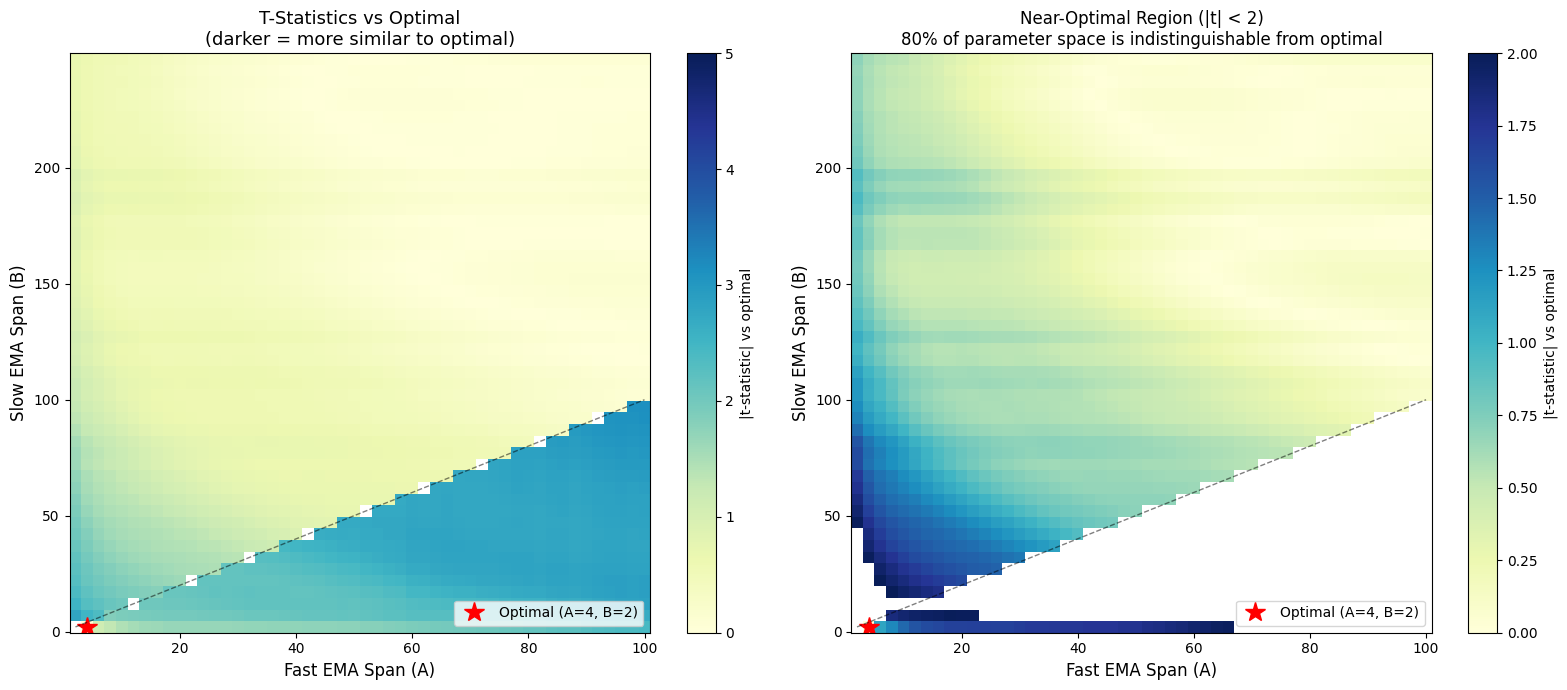

In [ ]:
# T-Test Heatmap: comparing each parameter combination against the optimal

import warnings
from scipy import stats as sp_stats

# Recompute daily strategy returns for each parameter combination
# Store returns for the optimal and compare

best_a_idx, best_b_idx = best_idx[1], best_idx[0]
best_a_val = A_vals[best_a_idx]
best_b_val = B_vals[best_b_idx]

# Get optimal strategy returns
fast_opt = gspc_close.ewm(span=int(best_a_val)).mean()
slow_opt = gspc_close.ewm(span=int(best_b_val)).mean()
sig_opt = fast_opt - slow_opt
sig_opt_norm = sig_opt / sig_opt.rolling(60).std()
sig_opt_norm = sig_opt_norm.clip(-2, 2)
daily_ret_all = gspc_close.pct_change()
opt_ret = (sig_opt_norm.shift(1) * daily_ret_all).dropna()
warmup = max(int(best_a_val), int(best_b_val)) + 60
opt_ret = opt_ret.iloc[warmup:]

# T-test grid: each combination vs optimal
tstat_grid = np.full((len(B_vals), len(A_vals)), np.nan)

for i, b_span in enumerate(B_vals):
    for j, a_span in enumerate(A_vals):
        fast_ema = gspc_close.ewm(span=a_span).mean()
        slow_ema = gspc_close.ewm(span=b_span).mean()
        signal = fast_ema - slow_ema
        signal_norm = signal / signal.rolling(60).std()
        signal_norm = signal_norm.clip(-2, 2)
        strat_ret = (signal_norm.shift(1) * daily_ret_all).dropna()
        warmup_local = max(a_span, b_span) + 60
        strat_ret = strat_ret.iloc[warmup_local:]

        # Align with optimal
        common_idx = strat_ret.index.intersection(opt_ret.index)
        if len(common_idx) > 252:
            diff = opt_ret.loc[common_idx] - strat_ret.loc[common_idx]
            std_diff = diff.std()
            if std_diff > 0:
                t_stat = diff.mean() / (std_diff / np.sqrt(len(diff)))
                tstat_grid[i, j] = abs(t_stat)
            else:
                # Identical strategies (e.g., comparing optimal to itself)
                tstat_grid[i, j] = 0.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Full t-test heatmap
im1 = ax1.pcolormesh(
    A_vals, B_vals, tstat_grid, cmap="YlGnBu", shading="auto", vmin=0, vmax=5
)
fig.colorbar(im1, ax=ax1, label="|t-statistic| vs optimal")
ax1.plot(
    best_a_val,
    best_b_val,
    "r*",
    markersize=15,
    label=f"Optimal (A={best_a_val}, B={best_b_val})",
)
ax1.plot([2, 100], [2, 100], "k--", linewidth=1, alpha=0.5)
ax1.set_xlabel("Fast EMA Span (A)", fontsize=12)
ax1.set_ylabel("Slow EMA Span (B)", fontsize=12)
ax1.set_title(
    "T-Statistics vs Optimal\n(darker = more similar to optimal)", fontsize=13
)
ax1.legend(fontsize=10, loc="lower right")

# Near-optimal region: mask where |t| > 2 (significantly different)
near_optimal = tstat_grid.copy()
near_optimal[near_optimal > 2] = np.nan  # Remove significantly different

im2 = ax2.pcolormesh(
    A_vals, B_vals, near_optimal, cmap="YlGnBu", shading="auto", vmin=0, vmax=2
)
fig.colorbar(im2, ax=ax2, label="|t-statistic| vs optimal")
ax2.plot(
    best_a_val,
    best_b_val,
    "r*",
    markersize=15,
    label=f"Optimal (A={best_a_val}, B={best_b_val})",
)
ax2.plot([2, 100], [2, 100], "k--", linewidth=1, alpha=0.5)

# Count near-optimal cells
n_near_optimal = np.sum(~np.isnan(near_optimal))
n_total = np.sum(~np.isnan(tstat_grid))
pct_near = 100 * n_near_optimal / n_total if n_total > 0 else 0

ax2.set_xlabel("Fast EMA Span (A)", fontsize=12)
ax2.set_ylabel("Slow EMA Span (B)", fontsize=12)
ax2.set_title(
    f"Near-Optimal Region (|t| < 2)\n{pct_near:.0f}% of parameter space is indistinguishable from optimal",
    fontsize=12,
)
ax2.legend(fontsize=10, loc="lower right")

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "systematic-trading-ttest-heatmap.png"),
    dpi=150,
    bbox_inches="tight",
)
print(f"Saved: {os.path.join(SAVE_DIR, 'systematic-trading-ttest-heatmap.png')}")
plt.show()